# Yield Curve Forecasting: FAVAR vs Taylor Rule

**Research question:** Does augmenting a Nelson-Siegel VAR with macro factors (FAVAR) improve yield-curve out-of-sample forecasts, and does it beat a Taylor-rule-style macro baseline?

**Data:** Gurkaynak-Sack-Wright (GSW) zero-coupon yields, 1M–30Y  
**Test period:** 2015-12 to 2025-12 (119 months, ~10 years)  
**Horizons:** h = 1, 6, 12 months ahead

## Model inventory

| § | Model | Type | Methodology |
|---|-------|------|-------------|
| 2a | Random Walk | Benchmark | No-change: $\hat{y}_{t+h} = y_t$ |
| 2b | Yield-VAR | Benchmark | VAR(1) on raw yield levels |
| 2c | NS-RW | Nelson-Siegel | NS factors with random-walk dynamics |
| 2d | Diebold-Li | Nelson-Siegel | Fixed-$\lambda$ NS, VAR(1) on factors |
| 2e | NS-VAR | Nelson-Siegel | Differenced VAR(2) on [level, slope, curvature] |
| 2f | FAVAR | Factor-augmented | NS + 3 PCA macro factors, VAR(2) |
| 2g | FAVAR-Key4 | Factor-augmented | NS + 2 PCA from KEY4 series, VAR(2) |
| 2h | Macro-OLS | Macro baseline | Per-tenor OLS with Taylor (1993) variables |
| 2i | Taylor Rule (EH) | Macro structural | VAR macro + Krippner SSR + EH |

## 0. Setup & Data Loading

*Prerequisite:* run `gsw_data_prep.ipynb` first to populate `../data/processed/`.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.api import VAR
try:
    from statsmodels.tools.sm_exceptions import ValueWarning
    warnings.filterwarnings('ignore', category=ValueWarning)
except ImportError:
    pass
warnings.filterwarnings('ignore', message='No frequency information was provided')

from scipy.optimize import minimize
from scipy import stats as _sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import VAR as _VAR_API

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
os.makedirs('figures', exist_ok=True)
os.makedirs('figures/gsw', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# =========================================================================
# Load all data from ../data/processed/ (written by gsw_data_prep.ipynb)
# =========================================================================
PROC = '../data/processed'

def _load(name):
    df = pd.read_csv(f'{PROC}/{name}.csv', index_col=0, parse_dates=True)
    df.index = df.index + pd.offsets.MonthEnd(0)
    return df

yields_monthly   = _load('yields_monthly')
yields_aligned   = _load('yields_aligned')
macro_aligned    = _load('macro_aligned')
ssr_monthly      = _load('ssr_monthly')
ns_factors       = _load('ns_factors')
pca_factors      = _load('pca_factors')
pca_fac_exp      = _load('pca_factors_exp')
pca_key4_factors = _load('pca_key4_factors')
favar_data       = _load('favar_data')
favar_diff       = _load('favar_diff')

_cfg = json.load(open(f'{PROC}/config.json'))
START_DATE      = _cfg['START_DATE']
END_DATE        = _cfg['END_DATE']
ZLB_THRESHOLD   = _cfg['ZLB_THRESHOLD']
MATURITIES      = _cfg['MATURITIES']
TENOR_LABELS    = _cfg['TENOR_LABELS']
KEY4_VARS       = _cfg['KEY4_VARS']
variance_ratios = np.array(_cfg['variance_ratios_3f'])
selected_macro_vars = json.load(open(f'{PROC}/selected_macro_vars.json'))

# Reconstruct PCA objects (no pickle — from saved numpy arrays)
def _load_pca(pp, sp):
    p = np.load(pp); s = np.load(sp)
    pca = PCA(n_components=int(p['n_components']))
    pca.components_ = p['components']
    pca.explained_variance_ = p['explained_variance']
    pca.explained_variance_ratio_ = p['explained_variance_ratio']
    pca.mean_ = p['mean']
    pca.n_components_ = int(p['n_components'])
    pca.n_features_in_ = p['components'].shape[1]
    sc = StandardScaler(); sc.mean_ = s['mean']; sc.scale_ = s['scale']
    sc.n_features_in_ = int(s['n_features'])
    return pca, sc

pca_model, scaler    = _load_pca(f'{PROC}/pca_model_3f.npz',   f'{PROC}/pca_scaler_3f.npz')
_pca_k4, _scaler_k4  = _load_pca(f'{PROC}/pca_model_key4.npz', f'{PROC}/pca_scaler_key4.npz')

# Derived objects used throughout
yield_cols    = list(yields_aligned.columns)
common_index  = yields_aligned.index
lam_series    = ns_factors['lambda']
ns_levels     = ns_factors[['level', 'slope', 'curvature']].dropna()
ns_diff       = ns_levels.diff().dropna()

def split_data(data, train_ratio=0.8, split_date=None, test_years=None):
    if split_date is not None:
        sp = pd.Timestamp(split_date)
        return data[data.index < sp], data[data.index >= sp], sp
    if test_years is not None:
        sp = (data.index[-1] - pd.DateOffset(years=test_years)) + pd.offsets.MonthEnd(0)
        return data[data.index <= sp], data[data.index > sp], sp
    n = len(data); n_tr = int(n * train_ratio); sp = data.index[n_tr]
    return data.iloc[:n_tr], data.iloc[n_tr:], sp

train_diff, test_diff, split_date = split_data(favar_diff, test_years=10)
train_ns_diff = ns_diff[ns_diff.index <= split_date]
test_ns_diff  = ns_diff[ns_diff.index > split_date]
test_dates    = yields_aligned.index[yields_aligned.index > split_date]
yields_actual_test = yields_aligned.loc[test_dates]

# Forecasting hyperparameters
VAR_LAGS = 2
HORIZONS = [1, 6, 12]

print(f'Data loaded. Split: {split_date:%Y-%m} | '
      f'Test: {test_dates[0]:%Y-%m} to {test_dates[-1]:%Y-%m} ({len(test_dates)} months)')
print(f'Tenors: {yield_cols}')
print(f'VAR_LAGS={VAR_LAGS}, HORIZONS={HORIZONS}')

Data loaded. Split: 2015-12 | Test: 2016-01 to 2025-12 (120 months)
Tenors: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
VAR_LAGS=2, HORIZONS=[1, 6, 12]


### Forecasting Protocol

- **Expanding window**: each model is refit at every test date using all history up to that point
- **h=1**: one-month-ahead; **h=6**: six-month-ahead; **h=12**: twelve-month-ahead
- **Multi-step**: iterated VAR with cumulative diff → level reconstruction for NS/FAVAR models
- **Direct h-step OLS**: used for Macro-OLS (lagged predictors, no iteration)
- **Evaluation**: RMSE and MAE by tenor; Diebold-Mariano HLN (1997) for pairwise significance

---
## 1. Function Definitions

All model and evaluation functions are defined here before any model is run.

| Function | Purpose |
|----------|---------|
| `fit_var_model` | Fit VAR(p) to training data |
| `recursive_var_forecast_refit` | Expanding-window VAR engine (h-step cumulative diff) |
| `factors_to_yields` | Reconstruct yields from NS factor forecasts |
| `recursive_taylor_yield_forecast` | Per-tenor expanding OLS with Taylor variables |
| `random_walk_forecast` | No-change h-step benchmark |
| `recursive_yield_var_forecast` | VAR(1) on raw yield levels |
| `dl_*` functions | Diebold-Li fixed-lambda NS |
| `ns_rw_yield_forecast` | NS factors with RW dynamics |
| `get_effective_rate` | Shadow-rate-adjusted FF series |
| `var_macro_path` | VAR(1) joint macro forecast for Taylor Rule |
| `taylor_rule_eh_forecast` | Three-stage EH Taylor Rule |
| `compute_rmse`, `compute_mae` | Evaluation metrics |
| `win_rate`, `metrics_by_tenor` | Win-rate and per-tenor RMSE/MAE |

In [3]:
### 1a. VAR fitting
def fit_var_model(train_data, lags=2):
    """Fit a VAR(lags) model to training data."""
    model = VAR(train_data)
    results = model.fit(lags)
    return results


# VAR lag order (keep fixed for comparability)
VAR_LAGS = 2
print(f"Using VAR lag order: {VAR_LAGS}")

Using VAR lag order: 2


In [4]:
### 1b. Core forecasting engine (VAR + Macro-OLS)
def recursive_var_forecast_refit(train_data, test_data, lags=2, horizon=1,
                                  ic=None, stability_fallback=False):
    """Expanding-window VAR forecast with configurable horizon.

    For horizon=1 this is a standard 1-step-ahead expanding-window VAR.
    For horizon>1 (h-step ahead), returns the CUMULATIVE diff over h periods
    so that: level_forecast[t+h] = ns_lag[origin] + returned_value.

    Parameters
    ----------
    train_data : pd.DataFrame
    test_data : pd.DataFrame
        Out-of-sample segment (forecast origins AND realized values for
        the expanding window).
    lags : int
        Maximum lag order (or fixed order when ic=None).
    horizon : int
        Forecast horizon in periods (months).
    ic : str or None
        Information criterion for automatic lag selection ('bic', 'aic', 'hqic').
        If None (default), uses the fixed lag order `lags`.
        Recommended for FAVAR/FAVAR-Key4 to combat overfitting with many state
        variables — near-unit-root or near-collinear inputs can produce large
        companion-matrix roots with fixed VAR(2).
    stability_fallback : bool
        If True, after fitting check max eigenvalue modulus of the companion
        matrix. If >= 1.0 (unstable), reduce lags by 1 and refit until stable
        or lags=1. Addresses explosive roots that can arise at the tail of the
        expanding window due to structural breaks (e.g., 2020 COVID shock).

    Returns
    -------
    pd.DataFrame
        horizon=1: forecasts indexed at each test date.
        horizon>1: cumulative h-step diff forecasts indexed at target
        dates (origin_date + horizon - 1 months, month-end aligned).
    """
    train_data = train_data.dropna().copy()
    test_data = test_data.dropna().copy()

    common_cols = [c for c in train_data.columns if c in test_data.columns]
    if len(common_cols) == 0:
        raise ValueError("No common columns between train_data and test_data")

    train_data = train_data[common_cols]
    test_data = test_data[common_cols]

    history = train_data.copy()
    forecasts = []
    target_dates = []

    for date in test_data.index:
        if len(history) <= lags:
            raise ValueError("Not enough history to fit VAR with the requested lag order")

        # Fit VAR: use IC-based lag selection if requested, otherwise fixed lags
        if ic is not None:
            results = VAR(history).fit(maxlags=lags, ic=ic)
        else:
            results = VAR(history).fit(lags)

        # Stability fallback: if companion matrix has roots >= 1, reduce lag order
        # until stable (or lags = 1). This prevents explosive forecasts caused by
        # overfitting at tail of expanding window (common in high-dim FAVAR states).
        if stability_fallback and results.k_ar > 1:
            while np.max(np.abs(results.roots)) >= 1.0 and results.k_ar > 1:
                results = VAR(history).fit(results.k_ar - 1)

        # Use actual fitted lag order (may differ from input lags when ic/fallback active)
        k_ar = results.k_ar
        y_last = history.values[-k_ar:]
        all_steps = results.forecast(y_last, steps=horizon)   # shape (horizon, n_vars)

        if horizon == 1:
            fc = all_steps[0]
            target_dates.append(date)
        else:
            # Cumulative sum = total change over h periods
            fc = all_steps.cumsum(axis=0)[-1]
            target = (date + pd.DateOffset(months=horizon - 1)) + pd.offsets.MonthEnd(0)
            target_dates.append(target)

        forecasts.append(fc)
        history = pd.concat([history, test_data.loc[[date]]], axis=0)

    return pd.DataFrame(forecasts, index=target_dates, columns=common_cols)
def factors_to_yields(factors_df, maturities, yield_cols, lam):
    """Convert Nelson–Siegel factors to yields at the given maturities.

    factors_df must have columns: ['level', 'slope', 'curvature'].

    lam can be:
    - scalar (same lambda for all dates), or
    - array-like of length len(factors_df) (date-varying lambda).
    """
    beta0 = factors_df['level'].to_numpy(dtype=float)
    beta1 = factors_df['slope'].to_numpy(dtype=float)
    beta2 = factors_df['curvature'].to_numpy(dtype=float)

    lam_arr = np.asarray(lam, dtype=float)
    if lam_arr.ndim == 0:
        lam_arr = np.full(len(factors_df), float(lam_arr))
    if len(lam_arr) != len(factors_df):
        raise ValueError("lam must be scalar or have the same length as factors_df")

    out = pd.DataFrame(index=factors_df.index, columns=yield_cols, dtype=float)

    for tau, col in zip(maturities, yield_cols):
        x = float(tau) / lam_arr  # fixed: match estimation form exp(-tau/lambda)
        with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
            term1 = (1.0 - np.exp(-x)) / x
        term1 = np.where(x == 0.0, 1.0, term1)
        term2 = term1 - np.exp(-x)
        out[col] = beta0 + beta1 * term1 + beta2 * term2

    return out


def recursive_taylor_yield_forecast(macro_df, yields_df, yield_cols, split_date, horizon=1):
    """Expanding-window OLS yield forecasts using only t-horizon information.

    For each maturity (yield column), estimates an expanding-window regression:
        y_t(m) = a + b' x_{t-h} + rho * y_{t-h}(m) + eps_t
    where h = horizon.

    For horizon=1 this is identical to the original 1-step OLS.
    For horizon>1 this is a direct h-step-ahead regression using predictors
    lagged by h periods (no look-ahead) and with the *refit window* ending
    at the forecast origin (t-h).

    Note: With the expanded macro panel, we restrict regressors to high-coverage
    series to avoid shrinking the sample to the intersection of many sparse
    predictors.
    """
    # Strict Taylor (1993) rule: inflation, output gap, Fed Funds rate only
    # Not the full 25-variable macro panel — keeps the benchmark clean and interpretable
    TAYLOR_VARS = ['inflation', 'output', 'fedfunds']
    macro_cols = [v for v in TAYLOR_VARS if v in macro_df.columns]

    macro_use = macro_df[macro_cols].copy()
    macro_lag = macro_use.shift(horizon)
    yields_lag = yields_df.shift(horizon)

    dates = yields_df.index
    test_dates = dates[dates >= split_date]

    forecasts = pd.DataFrame(index=test_dates, columns=yield_cols, dtype=float)

    X_cols = ['y_lag'] + macro_cols

    for col in yield_cols:
        parts = [yields_df[col], yields_lag[col]]
        if len(macro_cols) > 0:
            parts.append(macro_lag)
        df = pd.concat(parts, axis=1).dropna()
        df.columns = ['y', 'y_lag'] + macro_cols

        for t in test_dates:
            if t not in df.index:
                continue

            # Forecast origin is t-horizon (month-end aligned)
            origin = (t - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)

            # Refit expanding window *only* on data available at the origin (no look-ahead)
            train_df = df.loc[df.index <= origin]
            if len(train_df) < 36:
                continue

            X = train_df[X_cols]
            X = sm.add_constant(X)
            y = train_df['y']
            model = sm.OLS(y, X).fit()

            # OLS on near-I(1) yields sometimes estimates y_lag > 1 (Hurwicz small-sample bias).
            # Capping rho post-estimation would distort the other joint OLS coefficients
            # (e.g. the negative b_fedfunds partially offsets the high rho), so we use
            # the unconstrained prediction here.
            X_t = df.loc[[t], X_cols]
            X_t_const = sm.add_constant(X_t, has_constant='add')
            forecasts.loc[t, col] = float(model.predict(X_t_const).iloc[0])

    return forecasts

In [5]:
### 1c. Benchmark and NS/DL functions
# =============================================================================
# STEP 2: BENCHMARK FUNCTIONS
# =============================================================================

# 2a. Random Walk (no-change)
def random_walk_forecast(yields_df, yield_cols, split_date, horizon=1):
    """h-step-ahead random walk: forecast = yield observed h periods ago."""
    test_dates = yields_df.index[yields_df.index >= split_date]
    return yields_df[yield_cols].shift(horizon).reindex(test_dates)


# 2b. VAR on yield levels
def recursive_yield_var_forecast(yields_df, yield_cols, split_date, lags=1, horizon=1):
    """Expanding-window VAR(lags) on yield LEVELS; iterated h-step forecast."""
    data    = yields_df[yield_cols].dropna()
    history = data.loc[data.index < split_date].copy()
    test    = data.loc[data.index >= split_date]
    forecasts, target_dates = [], []
    for date in test.index:
        if len(history) <= lags:
            break
        res    = VAR(history).fit(lags)
        y_last = history.values[-lags:]
        fc     = res.forecast(y_last, steps=horizon)[-1]
        forecasts.append(fc)
        if horizon == 1:
            target_dates.append(date)
        else:
            target_dates.append(
                (date + pd.DateOffset(months=horizon - 1)) + pd.offsets.MonthEnd(0)
            )
        history = pd.concat([history, test.loc[[date]]], axis=0)
    return pd.DataFrame(forecasts, index=target_dates, columns=yield_cols)


# 2c. Diebold-Li (2005) with fixed lambda
# NOTE: This notebook uses the exp(-tau/lambda) parameterization with tau in YEARS.
# Diebold-Li's canonical lambda=0.0609 is for exp(-kappa*tau) with tau in MONTHS; here that implies:
#   kappa_year = 0.0609 * 12   and   lambda_year = 1 / kappa_year ≈ 1.368 years (peak curvature ≈ 2.5y).
DL_LAMBDA = 1.0 / (0.0609 * 12.0)

def dl_ns_loadings(maturities, lam=DL_LAMBDA):
    """Return (level, slope, curvature) loadings for fixed-lambda NS."""
    tau = np.array(maturities, dtype=float)
    x   = tau / lam
    with np.errstate(divide='ignore', invalid='ignore'):
        sl = np.where(x == 0.0, 1.0, (1.0 - np.exp(-x)) / x)
    cl = sl - np.exp(-x)
    return np.ones_like(tau), sl, cl


def fit_dl_factors(yields_df, yield_cols, maturities, lam=DL_LAMBDA):
    """OLS-fit Diebold-Li NS factors each month with fixed lambda."""
    L, S, C = dl_ns_loadings(maturities, lam)
    X = np.column_stack([L, S, C])
    records = []
    for date, row in yields_df[yield_cols].iterrows():
        y = row.values.astype(float)
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            records.append({'date': date, 'level': float('nan'),
                            'slope': float('nan'), 'curvature': float('nan')})
            continue
        beta, *_ = np.linalg.lstsq(X[mask], y[mask], rcond=None)
        records.append({'date': date, 'level': beta[0], 'slope': beta[1], 'curvature': beta[2]})
    return pd.DataFrame(records).set_index('date')


def dl_factors_to_yields(factors_df, maturities, yield_cols, lam=DL_LAMBDA):
    """Reconstruct yields from Diebold-Li factors (fixed lambda)."""
    L, S, C = dl_ns_loadings(maturities, lam)
    b0 = factors_df['level'].values
    b1 = factors_df['slope'].values
    b2 = factors_df['curvature'].values
    out = pd.DataFrame(index=factors_df.index, columns=yield_cols, dtype=float)
    for j, col in enumerate(yield_cols):
        out[col] = b0 * L[j] + b1 * S[j] + b2 * C[j]
    return out


def recursive_dl_yield_forecast(yields_df, yield_cols, maturities, split_date,
                                 lam=DL_LAMBDA, lags=1, horizon=1):
    """Diebold-Li: expanding-window VAR(lags) on DL factors; h-step forecast."""
    dl_fac    = fit_dl_factors(yields_df, yield_cols, maturities, lam)
    fac_train = dl_fac.loc[dl_fac.index < split_date].dropna()
    fac_test  = dl_fac.loc[dl_fac.index >= split_date].dropna()
    history   = fac_train.copy()
    fac_fcs, target_dates = [], []
    for date in fac_test.index:
        if len(history) <= lags:
            break
        res    = VAR(history).fit(lags)
        y_last = history.values[-lags:]
        fc     = res.forecast(y_last, steps=horizon)[-1]
        fac_fcs.append(fc)
        if horizon == 1:
            target_dates.append(date)
        else:
            target_dates.append(
                (date + pd.DateOffset(months=horizon - 1)) + pd.offsets.MonthEnd(0)
            )
        history = pd.concat([history, fac_test.loc[[date]]], axis=0)
    fc_fac = pd.DataFrame(fac_fcs, index=target_dates, columns=dl_fac.columns)
    return dl_factors_to_yields(fc_fac, maturities, yield_cols, lam)


print('Benchmark functions defined: RandomWalk, YieldVAR, Diebold-Li')
print(f'  Diebold-Li fixed lambda: {DL_LAMBDA:.4f} (years)')

# 2d. NS-RW: Nelson-Siegel Random Walk (Caldeira et al. 2023, Sec 4.1)
# Non-stationary factor assumption (Phi=I): each NS beta follows a RW.
# Forecast: beta_{t+h|t} = beta_t, lambda_{t+h|t} = lambda_t.
# Yields reconstructed via NS — distinct from raw-yield RW because NS
# imposes a smooth cross-maturity constraint and propagates time-varying lambda.
def ns_rw_yield_forecast(ns_factors_df, yields_df, yield_cols, maturities,
                          split_date, horizon=1):
    test_dates = yields_df.index[yields_df.index >= split_date]
    tau = np.array(maturities, dtype=float)
    forecasts = []
    for target in test_dates:
        origin_approx = (target - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)
        avail = ns_factors_df.index[ns_factors_df.index <= origin_approx]
        if len(avail) == 0:
            forecasts.append([np.nan] * len(yield_cols))
            continue
        origin = avail[-1]
        b0  = ns_factors_df.loc[origin, 'level']
        b1  = ns_factors_df.loc[origin, 'slope']
        b2  = ns_factors_df.loc[origin, 'curvature']
        lam = ns_factors_df.loc[origin, 'lambda']
        x   = tau / lam
        with np.errstate(divide='ignore', invalid='ignore'):
            sl = np.where(x == 0.0, 1.0, (1.0 - np.exp(-x)) / x)
        cl = sl - np.exp(-x)
        forecasts.append((b0 + b1 * sl + b2 * cl).tolist())
    return pd.DataFrame(forecasts, index=test_dates, columns=yield_cols)

print('NS-RW function defined (Caldeira et al. 2023 non-stationary insight)')

Benchmark functions defined: RandomWalk, YieldVAR, Diebold-Li


  Diebold-Li fixed lambda: 1.3684 (years)
NS-RW function defined (Caldeira et al. 2023 non-stationary insight)


In [6]:
### 1d. Taylor Rule (EH) functions
# =============================================================================
# IMPROVED TAYLOR RULE — Function Definitions
# VAR Macro Forecasting + Shadow Rate Integration
# =============================================================================
# Literature basis:
#   Ang & Piazzesi (2003)  — macro VAR + yield-curve model
#   Monch (2007)           — forecasting with macro factors
#   Krippner (2015)        — shadow short rates for ZLB periods
# =============================================================================

from statsmodels.tsa.api import VAR as _VAR_API
import statsmodels.api as sm


def get_effective_rate(macro_df, ssr_df, zlb_threshold=ZLB_THRESHOLD):
    # Build effective-FF series: replace FF with SSR when FF <= ZLB_THRESHOLD.
    # During ZLB episodes the observed FF rate is floored at 0 and no longer
    # reflects true monetary accommodation (Krippner 2015).
    ff = macro_df["fedfunds"].copy()
    if ssr_df is None or ssr_df.empty:
        return ff
    common = ff.index.intersection(ssr_df.index)
    at_zlb = ff.loc[common] <= zlb_threshold
    eff = ff.copy()
    eff.loc[common[at_zlb]] = ssr_df.loc[common[at_zlb], "US_SSR"].values
    return eff


def var_macro_path(macro_df, origin, n_steps, macro_cols, eff_ff=None, var_lags=1):
    # VAR(var_lags) expanding-window joint forecast of macro_cols.
    # Returns dict {col: np.array(n_steps)} of multi-step forecasts.
    # Captures cross-variable macro dynamics (Ang & Piazzesi 2003, Monch 2007).
    df = macro_df[macro_cols].copy()
    if eff_ff is not None and "fedfunds" in macro_cols:
        df["fedfunds"] = eff_ff

    train = df.loc[df.index <= origin].dropna()
    min_obs = max(36, var_lags * len(macro_cols) + 10)
    if len(train) < min_obs:
        return {col: np.full(n_steps, np.nan) for col in macro_cols}

    try:
        model  = _VAR_API(train)
        result = model.fit(var_lags, trend="c", ic=None)
        last_p = train.values[-var_lags:]
        fc     = result.forecast(last_p, steps=n_steps)
        return {col: fc[:, i] for i, col in enumerate(macro_cols)}
    except Exception:
        # Fallback: independent AR(1) per variable if VAR fails
        paths = {}
        for i, col in enumerate(macro_cols):
            s = train[col].values
            if len(s) < 4:
                paths[col] = np.full(n_steps, np.nan)
                continue
            a, b = np.polyfit(s[:-1], s[1:], 1)
            x = float(s[-1])
            path = []
            for _ in range(n_steps):
                x = b + a * x
                path.append(x)
            paths[col] = np.array(path)
        return paths


def taylor_rule_eh_forecast(macro_df, yield_cols, split_date, horizon=1,
                             maturities=None, ssr_df=None):
    # Expectations Hypothesis Taylor Rule with VAR macro forecasting + shadow rates.
    #
    # Stage 1  — VAR(1) expanding-window joint forecast of [inflation, output, fedfunds]
    # Stage 2  — Taylor Rule target + interest-rate smoothing (rho estimated by OLS)
    #              i*_t = (r* - 0.5*pi*) + 1.5*pi_t + 0.5*output_t
    #              i_t  = rho * eff_FF_{t-1} + (1 - rho) * i*_t
    #              rho estimated on shadow-rate-adjusted FF history (no ZLB floor bias)
    # Stage 3  — EH: y_t(m) = mean(FF_path[h-1 : h-1+m_months])
    R_STAR  = 2.0   # neutral real rate (%)
    PI_STAR = 2.0   # inflation target (%)

    if maturities is None:
        maturities = MATURITIES
    mat_months = [max(1, int(round(m * 12))) for m in maturities]
    n_steps    = (horizon - 1) + max(mat_months)

    output_col = "output_gap" if "output_gap" in macro_df.columns else "output"
    macro_cols = ["inflation", output_col, "fedfunds"]

    split_ts   = pd.Timestamp(split_date)
    test_dates = macro_df.index[macro_df.index >= split_ts]
    out        = pd.DataFrame(np.nan, index=test_dates, columns=yield_cols)

    # Pre-build effective FF series (shadow-rate-adjusted) for the full sample
    eff_ff = get_effective_rate(macro_df, ssr_df)

    for t in test_dates:
        origin = (t - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)
        hist   = macro_df[macro_df.index <= origin].dropna(
            subset=["inflation", output_col, "fedfunds"])
        if len(hist) < 36:
            continue

        # Stage 1: VAR(1) joint macro forecast — captures inflation-output-FF dynamics
        macro_paths = var_macro_path(
            macro_df, origin, n_steps, macro_cols, eff_ff=eff_ff, var_lags=1
        )
        pi_path     = macro_paths["inflation"]
        output_path = macro_paths[output_col]
        if np.any(np.isnan(pi_path)) or np.any(np.isnan(output_path)):
            continue

        # Stage 2: Estimate rho on shadow-rate-adjusted history (avoids ZLB floor bias)
        # Constrained estimation consistent with i_t = rho*i_{t-1} + (1-rho)*i*_t:
        #   (i_t - i*_t) = rho * (i_{t-1} - i*_t) + eps_t    (no intercept)
        pi_hist     = hist["inflation"].values
        out_hist    = hist[output_col].values
        eff_ff_hist = eff_ff.loc[hist.index].values
        i_star_hist = (R_STAR - 0.5 * PI_STAR) + 1.5 * pi_hist + 0.5 * out_hist

        y_rho = eff_ff_hist[1:] - i_star_hist[1:]
        x_rho = (eff_ff_hist[:-1] - i_star_hist[1:]).reshape(-1, 1)
        try:
            rho_hat = sm.OLS(y_rho, x_rho).fit().params[0]
            rho     = float(np.clip(rho_hat, 0.0, 0.99))
        except Exception:
            rho = 0.85  # fallback smoothing parameter

        # Forward short-rate path starting from shadow-rate-adjusted FF at origin
        ff0         = float(eff_ff.loc[eff_ff.index <= origin].iloc[-1])
        i_star_path = (R_STAR - 0.5 * PI_STAR) + 1.5 * pi_path + 0.5 * output_path
        ff_path     = np.empty(n_steps)
        ff_prev     = ff0
        for j in range(n_steps):
            ff_path[j] = rho * ff_prev + (1.0 - rho) * i_star_path[j]
            ff_prev    = ff_path[j]

        # Stage 3: EH — yield = average expected short rate over m months
        start_idx = horizon - 1
        for col, m_months in zip(yield_cols, mat_months):
            out.loc[t, col] = ff_path[start_idx : start_idx + m_months].mean()

    return out


def macro_ols_ssr_forecast(macro_df, yields_df, yield_cols, split_date, horizon=1,
                           ssr_df=None, zlb_threshold=ZLB_THRESHOLD):
    """Macro-OLS variant: replaces the Fed Funds regressor with SSR-adjusted effective FF."""
    if ssr_df is None or ssr_df.empty or "fedfunds" not in macro_df.columns:
        return recursive_taylor_yield_forecast(
            macro_df=macro_df,
            yields_df=yields_df,
            yield_cols=yield_cols,
            split_date=split_date,
            horizon=horizon,
        )

    macro_adj = macro_df.copy()
    macro_adj["fedfunds"] = get_effective_rate(macro_df, ssr_df, zlb_threshold=zlb_threshold)
    return recursive_taylor_yield_forecast(
        macro_df=macro_adj,
        yields_df=yields_df,
        yield_cols=yield_cols,
        split_date=split_date,
        horizon=horizon,
    )


print("Improved Taylor Rule functions defined:")
print("  get_effective_rate       — shadow-rate-adjusted effective FF series")
print("  var_macro_path           — VAR(1) joint macro forecast (inflation + output + FF)")
print("  taylor_rule_eh_forecast  — EH: VAR macro + Taylor Rule (rho constrained OLS) + avg short rates")
print("  macro_ols_ssr_forecast   — Macro-OLS with SSR-adjusted Fed Funds regressor")
print()
print("Improvements over naive AR(1):")
print("  1. Joint VAR(1) captures cross-variable macro dynamics (Ang & Piazzesi 2003)")
print("  2. Shadow rate used as effective FF during ZLB (Krippner 2015)")
print("  3. rho estimated under Taylor smoothing restriction => internally consistent")


Improved Taylor Rule functions defined:
  get_effective_rate       — shadow-rate-adjusted effective FF series
  var_macro_path           — VAR(1) joint macro forecast (inflation + output + FF)
  taylor_rule_eh_forecast  — EH: VAR macro + Taylor Rule (rho constrained OLS) + avg short rates
  macro_ols_ssr_forecast   — Macro-OLS with SSR-adjusted Fed Funds regressor

Improvements over naive AR(1):
  1. Joint VAR(1) captures cross-variable macro dynamics (Ang & Piazzesi 2003)
  2. Shadow rate used as effective FF during ZLB (Krippner 2015)
  3. rho estimated under Taylor smoothing restriction => internally consistent


In [ ]:
# [TVR-INJECTED]
# =============================================================================
# Taylor Rule (TVR) — Time-Varying Neutral Rate via TIPS (DFII5)
# =============================================================================
# Motivation (Holston-Laubach-Williams 2017, 2023):
#   Post-GFC r* fell from ~2-3% to ~0.5%.  Fixing r*=2% in the Taylor Rule
#   overshoots FF during 2015-2021 and mis-calibrates the entire EH yield path.
# Implementation:
#   At each forecast origin t, use the 5-year TIPS real yield (DFII5, monthly
#   average) as a market-implied, real-time proxy for r*.  Pre-2003 (when TIPS
#   are unavailable), fall back to the pre-GFC consensus of 3.0%.
# Data source: FRED series DFII5 (5-year TIPS yield, daily -> monthly mean).
#   Saved to data/rstar_monthly.csv by the TVR injection script.
# =============================================================================

import os as _os

def _load_rstar(path="data/rstar_monthly.csv"):
    """Load time-varying r* (TIPS-based) from CSV."""
    if not _os.path.exists(path):
        print(f"WARNING: {path} not found — TVR will fall back to r*=2.0%")
        return None
    _df = pd.read_csv(path, index_col=0, parse_dates=True)
    _df.index = _df.index.to_period('M').to_timestamp('M')
    return _df

rstar_monthly = _load_rstar()
if rstar_monthly is not None:
    print(f"r* (TIPS-based) loaded: {len(rstar_monthly)} months, "
          f"{rstar_monthly.index[0].strftime('%Y-%m')} to "
          f"{rstar_monthly.index[-1].strftime('%Y-%m')}")
    _key_years = [2005, 2009, 2012, 2015, 2018, 2020, 2022, 2024]
    for _y in _key_years:
        _v = rstar_monthly.loc[str(_y), 'rstar'].mean()
        print(f"  {_y}: r* = {_v:.2f}%")
else:
    print("r* series unavailable — TVR will use constant r*=2.0% (same as EH)")


def taylor_rule_eh_tvr_forecast(macro_df, yield_cols, split_date, horizon=1,
                                 maturities=None, ssr_df=None, rstar_df=None):
    """
    EH Taylor Rule with time-varying neutral rate r* (DFII5 TIPS proxy).

    Identical to taylor_rule_eh_forecast except R_STAR is read from rstar_df
    at each forecast origin (last available observation, no look-ahead).
    This directly tests whether the post-GFC r* decline explains EH failure.

    Parameters
    ----------
    rstar_df : pd.DataFrame or None
        Monthly r* series with column 'rstar'.  If None, falls back to 2.0%.
    """
    PI_STAR = 2.0   # inflation target (%), unchanged

    if maturities is None:
        maturities = MATURITIES
    mat_months = [max(1, int(round(m * 12))) for m in maturities]
    n_steps    = (horizon - 1) + max(mat_months)

    output_col = "output_gap" if "output_gap" in macro_df.columns else "output"
    macro_cols = ["inflation", output_col, "fedfunds"]

    split_ts   = pd.Timestamp(split_date)
    test_dates = macro_df.index[macro_df.index >= split_ts]
    out        = pd.DataFrame(np.nan, index=test_dates, columns=yield_cols)

    eff_ff = get_effective_rate(macro_df, ssr_df)

    for t in test_dates:
        origin = (t - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)
        hist   = macro_df[macro_df.index <= origin].dropna(
            subset=["inflation", output_col, "fedfunds"])
        if len(hist) < 36:
            continue

        # --- Time-varying r* at forecast origin (real-time, no look-ahead) ---
        if rstar_df is not None and not rstar_df.empty:
            _r_avail = rstar_df.loc[rstar_df.index <= origin, 'rstar']
            r_star   = float(_r_avail.iloc[-1]) if len(_r_avail) > 0 else 2.0
        else:
            r_star = 2.0  # fallback = constant EH

        # Stage 1: VAR(1) joint macro forecast
        macro_paths = var_macro_path(
            macro_df, origin, n_steps, macro_cols, eff_ff=eff_ff, var_lags=1
        )
        pi_path     = macro_paths["inflation"]
        output_path = macro_paths[output_col]
        if np.any(np.isnan(pi_path)) or np.any(np.isnan(output_path)):
            continue

        # Stage 2: Taylor Rule with time-varying r* + OLS rho estimation
        pi_hist     = hist["inflation"].values
        out_hist    = hist[output_col].values
        eff_ff_hist = eff_ff.loc[hist.index].values
        i_star_hist = (r_star - 0.5 * PI_STAR) + 1.5 * pi_hist + 0.5 * out_hist

        y_rho = eff_ff_hist[1:] - i_star_hist[1:]
        x_rho = (eff_ff_hist[:-1] - i_star_hist[1:]).reshape(-1, 1)
        try:
            rho_hat = sm.OLS(y_rho, x_rho).fit().params[0]
            rho     = float(np.clip(rho_hat, 0.0, 0.99))
        except Exception:
            rho = 0.85

        ff0         = float(eff_ff.loc[eff_ff.index <= origin].iloc[-1])
        i_star_path = (r_star - 0.5 * PI_STAR) + 1.5 * pi_path + 0.5 * output_path
        ff_path     = np.empty(n_steps)
        ff_prev     = ff0
        for j in range(n_steps):
            ff_path[j] = rho * ff_prev + (1.0 - rho) * i_star_path[j]
            ff_prev    = ff_path[j]

        # Stage 3: EH — yield = average expected short rate over m months
        start_idx = horizon - 1
        for col, m_months in zip(yield_cols, mat_months):
            out.loc[t, col] = ff_path[start_idx : start_idx + m_months].mean()

    return out


print("taylor_rule_eh_tvr_forecast defined.")
print("  Uses time-varying r* from TIPS (DFII5) instead of constant r*=2%.")


In [7]:
### 1e. Evaluation metrics
def compute_rmse(actual, predicted):
    # Root Mean Squared Error, dropping NaN pairs
    aligned = pd.concat([actual.rename('actual'), predicted.rename('pred')], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan
    return float(np.sqrt(mean_squared_error(aligned['actual'], aligned['pred'])))


def compute_mae(actual, predicted):
    # Mean Absolute Error, dropping NaN pairs
    aligned = pd.concat([actual.rename('actual'), predicted.rename('pred')], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan
    return float(np.mean(np.abs(aligned['actual'] - aligned['pred'])))


def win_rate(actual, fc_a, fc_b):
    # Share of dates where model A is closer to actual than model B (absolute error)
    df = pd.concat([
        actual.rename('actual'),
        fc_a.rename('a'),
        fc_b.rename('b'),
    ], axis=1).dropna()
    if len(df) == 0:
        return np.nan
    err_a = (df['actual'] - df['a']).abs()
    err_b = (df['actual'] - df['b']).abs()
    return float((err_a < err_b).mean())


def metrics_by_tenor(y_actual: pd.DataFrame, forecasts: dict):
    # Per-tenor RMSE and MAE for a dict of model forecasts
    tenors = list(y_actual.columns)
    model_names = list(forecasts.keys())
    rmse_df = pd.DataFrame(index=tenors, columns=model_names, dtype=float)
    mae_df  = pd.DataFrame(index=tenors, columns=model_names, dtype=float)
    for tenor in tenors:
        for name, fc in forecasts.items():
            rmse_df.loc[tenor, name] = compute_rmse(y_actual[tenor], fc[tenor])
            mae_df.loc[tenor, name]  = compute_mae(y_actual[tenor], fc[tenor])
    return rmse_df, mae_df

In [8]:
# ============================================================
# Diagnostic helper setup
# Refits each model once at the final expanding-window origin
# for a clean, single-snapshot coefficient review.
# ============================================================
from statsmodels.tsa.api import VAR as _DVAR
import statsmodels.api as _DSM
from pathlib import Path as _DPath

DIAG_OUTDIR = _DPath('results/regression_diagnostics')
DIAG_OUTDIR.mkdir(parents=True, exist_ok=True)

# Final expanding-window origin for h=1 diagnostics
_diag_test_idx = yields_aligned.index[yields_aligned.index >= split_date]
_diag_origin = (_diag_test_idx.max() - pd.DateOffset(months=1)) + pd.offsets.MonthEnd(0)
print(f'Diagnostic origin (final h=1 expanding-window origin): {_diag_origin.date()}')

def _diag_fit_var(df, lags):
    train = df.loc[df.index <= _diag_origin].dropna()
    return _DVAR(train).fit(lags)

def _diag_var_print(res, label):
    roots = np.abs(res.roots)
    stable = bool(np.all(roots < 1.0))
    status = '[STABLE]' if stable else '[UNSTABLE - investigate!]'
    print()
    print('='*64)
    print(f'VAR DIAGNOSTICS: {label}')
    print(f'  Obs: {res.nobs}  |  Lags: {res.k_ar}  |  Equations: {res.neqs}')
    print(f'  AIC: {res.aic:.3f}  |  BIC: {res.bic:.3f}  |  HQIC: {res.hqic:.3f}')
    print(f'  Max eigenvalue modulus: {roots.max():.4f}  {status}')
    l1_rows = [r for r in res.params.index if r == 'const' or 'L1.' in r]
    print('  Lag-1 coefficients (rows = RHS terms, cols = LHS equations):')
    print(res.params.loc[l1_rows].round(4).to_string())
    print(f'  Note: lag shown = {res.k_ar} (single final-origin refit;'
          ' BIC/fallback runs may select fewer lags at earlier origins)')

def _diag_save_var(res, fname):
    fpath = DIAG_OUTDIR / fname
    with open(fpath, 'w', encoding='utf-8') as _f:
        _f.write(str(res.summary()))
    print(f'  [exported] {fpath.as_posix()}')


Diagnostic origin (final h=1 expanding-window origin): 2025-11-30


---
## 2. h=1 Forecast Runs

Each model section contains: (1) methodology, (2) key parameters, (3) the h=1 run.
Multi-horizon runs (h=1,6,12) are in Section 3.

### 2a–b. Benchmark Models: Random Walk & Yield-VAR

**Random Walk:** $\hat{y}^{(m)}_{t+h} = y^{(m)}_t$  
No model — the forecast is simply the last observed yield.
This is the hardest benchmark to beat at h=1 due to near-unit-root behaviour of yields.

**Yield-VAR:** VAR(1) on all 11 raw yield levels simultaneously.  
Captures cross-maturity dynamics without imposing a parametric shape.

### 2c. NS-RW — Nelson-Siegel Random Walk

Nelson-Siegel with **random-walk factor dynamics** (Caldeira et al. 2023, Sec 4.1).  
Non-stationary assumption: each $\beta_t$ follows a martingale.  
Forecast: $\hat{\beta}_{t+h|t} = \beta_t$, $\hat{\lambda}_{t+h|t} = \lambda_t$.  
Yields reconstructed via NS formula — imposes smooth cross-maturity shape unlike the raw Yield-RW.

### 2d. Diebold-Li — Fixed-Lambda Nelson-Siegel VAR(1)

Diebold-Li (2005) fix $\lambda$ at its empirically motivated value ($\lambda = 1/(0.0609 \times 12) \approx 1.37$ years, peak curvature at ~30 months).  
Monthly OLS cross-section extracts [level, slope, curvature] at fixed $\lambda$.  
Expanding-window VAR(1) on the 3 factors, then yield reconstruction.

**Parameters:** `DL_LAMBDA = 1.0 / (0.0609 * 12)`

In [9]:
# --- Run benchmarks + NS-RW + Diebold-Li (h=1) ---
print('Running benchmarks (h=1)...')
yields_forecast_rw = random_walk_forecast(
    yields_aligned, yield_cols, split_date, horizon=1)
print('  [OK] Random Walk')

yields_forecast_yvar = recursive_yield_var_forecast(
    yields_aligned, yield_cols, split_date, lags=1, horizon=1)
print('  [OK] Yield-VAR')

yields_forecast_ns_rw = ns_rw_yield_forecast(
    ns_factors, yields_aligned, yield_cols, MATURITIES, split_date, horizon=1)
print('  [OK] NS-RW')

yields_forecast_dl = recursive_dl_yield_forecast(
    yields_aligned, yield_cols, MATURITIES, split_date, lags=1, horizon=1)
print('  [OK] Diebold-Li')

Running benchmarks (h=1)...
  [OK] Random Walk


  [OK] Yield-VAR
  [OK] NS-RW


  [OK] Diebold-Li


In [10]:
# --- [DIAG] Yield-VAR(1): coefficient snapshot ---
# NOTE: Yield-VAR(1) on level yields EXPECTED to show large companion-matrix roots.
# 11 highly-correlated near-unit-root tenors create multicollinearity that inflates
# individual lag coefficients while their sum remains ~1. This is NOT a forecasting
# problem — Yield-VAR achieves best h=1 RMSE (0.193) precisely because short-horizon
# level persistence is the dominant signal. No stability fix needed here.
# Yields are near-unit-root: Lag-1 diagonal coefficients should be ~0.95-1.0.
_yvar_diag_res = _diag_fit_var(yields_aligned[yield_cols].dropna(), lags=1)
_diag_var_print(_yvar_diag_res, 'Yield-VAR(1) on raw yield levels')
_diag_save_var(_yvar_diag_res, 'yield_var_l1_diag.txt')

# --- [DIAG] Diebold-Li VAR(1): coefficient snapshot ---
# Level factor ~ 5-8% (persistent); slope mean-reverts; curvature transient.
_dl_fac_diag = fit_dl_factors(yields_aligned, yield_cols, MATURITIES, lam=DL_LAMBDA).dropna()
_dl_diag_res = _diag_fit_var(_dl_fac_diag, lags=1)
_diag_var_print(_dl_diag_res, f'Diebold-Li VAR(1) on fixed-lambda NS factors (lambda={DL_LAMBDA:.4f} yr)')
_diag_save_var(_dl_diag_res, 'diebold_li_var_l1_diag.txt')



VAR DIAGNOSTICS: Yield-VAR(1) on raw yield levels
  Obs: 490  |  Lags: 1  |  Equations: 11
  AIC: -83.319  |  BIC: -82.189  |  HQIC: -82.875
  Max eigenvalue modulus: 2.9413  [UNSTABLE - investigate!]
  Lag-1 coefficients (rows = RHS terms, cols = LHS equations):
             1M       3M       6M       1Y       2Y       3Y       5Y       7Y     10Y      20Y      30Y
const    0.0842   0.0902   0.0891   0.0807   0.0634   0.0507   0.0391   0.0383  0.0441   0.0617   0.0704
L1.1M   -0.2660  -0.3609  -0.5584  -0.7970  -0.7665  -0.6643  -0.5301  -0.4686 -0.4227  -0.2172   0.1153
L1.3M    1.0755   1.3199   2.7513   4.2367   3.9118   3.2955   2.5982   2.3088  2.0564   0.6654  -1.6338
L1.6M    2.2899  -0.5045  -5.7625 -10.1099  -9.2878  -7.6850  -5.7746  -4.9037 -4.1338  -0.6413   5.1043
L1.1Y   -6.1788   1.1660  10.8809  17.5357  15.7147  12.8873   9.1149   7.2127  5.6567   0.0324  -9.9764
L1.2Y   11.1688  -4.0109 -21.9859 -34.0354 -32.0457 -26.7360 -17.7467 -12.9634 -9.4569   1.3217  23.9209


  [exported] results/regression_diagnostics/diebold_li_var_l1_diag.txt


### 2e. NS-VAR — Nelson-Siegel VAR(2)

**State vector:** $[\Delta\beta_0,\ \Delta\beta_1,\ \Delta\beta_2]_t^\top$

**Algorithm:**
1. First-difference NS factors to induce stationarity
2. Fit VAR(2) expanding window
3. Cumulate h forecasted differences → factor level forecast
4. Reconstruct yields via NS formula with random-walk $\lambda$

This is the structured benchmark: yield-curve dynamics without any macro information.  
**Parameters:** `VAR_LAGS = 2`

In [11]:
# NS-VAR h=1 run
print('Running NS-VAR (h=1)...')
nsvar_forecasts_diff = recursive_var_forecast_refit(train_ns_diff, test_ns_diff, lags=VAR_LAGS)

_common_ns = test_diff.index.intersection(nsvar_forecasts_diff.index).intersection(yields_aligned.index)
_ns_lag     = ns_levels.shift(1).loc[_common_ns]
_lam_lag_ns = lam_series.shift(1).reindex(_common_ns).fillna(lam_series.median())
_ns_fc_nsv  = _ns_lag + nsvar_forecasts_diff.reindex(_common_ns)[['level', 'slope', 'curvature']]
yields_forecast_nsvar = factors_to_yields(_ns_fc_nsv, MATURITIES, yield_cols, lam=_lam_lag_ns.values)

_rmse_ns = yields_actual_test.reindex(yields_forecast_nsvar.index)
_rmse_ns = float(np.sqrt(np.nanmean((yields_forecast_nsvar.values - _rmse_ns.values)**2)))
print(f'  [OK] NS-VAR  avg RMSE h=1: {_rmse_ns:.4f}')

Running NS-VAR (h=1)...


  [OK] NS-VAR  avg RMSE h=1: 0.2054


In [12]:
# --- [DIAG] NS-VAR(2): coefficient snapshot ---
# VAR on first-differenced NS factors: coefficients should be small;
# stability (max modulus < 1) should hold. Check whether macro augmentation
# in FAVAR later destabilises the system.
_nsvar_diag_res = _diag_fit_var(ns_diff[['level', 'slope', 'curvature']], lags=VAR_LAGS)
_diag_var_print(_nsvar_diag_res,
    f'NS-VAR({VAR_LAGS}) on first-differenced NS factors [level, slope, curvature]')
_diag_save_var(_nsvar_diag_res, 'ns_var_l2_diag.txt')



VAR DIAGNOSTICS: NS-VAR(2) on first-differenced NS factors [level, slope, curvature]
  Obs: 488  |  Lags: 2  |  Equations: 3
  AIC: -5.066  |  BIC: -4.885  |  HQIC: -4.995
  Max eigenvalue modulus: 5.7679  [UNSTABLE - investigate!]
  Lag-1 coefficients (rows = RHS terms, cols = LHS equations):
               level   slope  curvature
const        -0.0124  0.0076    -0.0153
L1.level      0.0116  0.2414     0.1153
L1.slope     -0.2282  0.3760     0.2725
L1.curvature  0.0106  0.0312     0.0495
  Note: lag shown = 2 (single final-origin refit; BIC/fallback runs may select fewer lags at earlier origins)
  [exported] results/regression_diagnostics/ns_var_l2_diag.txt


### 2f. FAVAR — Factor-Augmented VAR(2)

Augments the NS state with 3 PCA macro factors (Bernanke, Boivin & Eliasz 2005).  

**State vector:** $[\Delta\beta_0,\ \Delta\beta_1,\ \Delta\beta_2,\ \Delta F_1,\ \Delta F_2,\ \Delta F_3]_t^\top$ — VAR(2)

$F_1, F_2, F_3$ are the first 3 principal components of the 25-variable macro panel (variables passing ≥90% coverage filter; explains 53% of macro variance).

**Research question:** does adding macro factors improve yield-curve forecasts?  
**Parameters:** `VAR_LAGS = 2`, full 25-series panel PCA

### 2g. FAVAR-Key4 — Focused Macro Panel VAR(2)

Motivated by Caldeira et al. (2023): macro factors matter most at long maturities and a targeted panel may outperform the full data-rich approach.

**State vector:** $[\Delta\beta_0,\ \Delta\beta_1,\ \Delta\beta_2,\ \Delta K_1,\ \Delta K_2]_t^\top$ — VAR(2)

$K_1, K_2$ are PCA factors from 4 series only: {CPI inflation, Fed Funds, UNRATE, INDPRO}.  
**Parameters:** `VAR_LAGS = 2`, KEY4 panel = {inflation, fedfunds, unrate, output}

In [13]:
# --- Model 1: FAVAR (NS factors + PCA macro factors) ---
# BIC lag selection + stability fallback prevents explosive companion-matrix roots
# that arise from VAR(2) overfitting on the 6-variable FAVAR state at tail of window.
favar_forecasts_diff = recursive_var_forecast_refit(
    train_diff, test_diff, lags=VAR_LAGS, ic='bic', stability_fallback=True)

# --- Model 2: NS-VAR (NS factors only) ---
ns_levels = ns_factors[['level', 'slope', 'curvature']].dropna()
ns_diff = ns_levels.diff().dropna()
train_ns_diff, test_ns_diff, _ = split_data(ns_diff, split_date=split_date)
nsvar_forecasts_diff = recursive_var_forecast_refit(train_ns_diff, test_ns_diff, lags=VAR_LAGS)

print("Forecasts generated!")
print(f"  FAVAR diff forecast shape: {favar_forecasts_diff.shape}")
print(f"  NS-VAR diff forecast shape: {nsvar_forecasts_diff.shape}")

# --- Evaluate on a common test index (intersection across models + yields) ---
yield_cols = list(yields_aligned.columns)

test_dates = test_diff.index.intersection(nsvar_forecasts_diff.index).intersection(yields_aligned.index)

# --- Convert 1-step diff forecasts to level forecasts (paper-style evaluation in levels) ---
ns_lag = ns_levels.shift(1).loc[test_dates]
ns_actual = ns_levels.loc[test_dates]

favar_ns_diff_fc = favar_forecasts_diff.reindex(test_dates)[['level', 'slope', 'curvature']]
nsvar_ns_diff_fc = nsvar_forecasts_diff.reindex(test_dates)[['level', 'slope', 'curvature']]

ns_forecast_levels_favar = ns_lag + favar_ns_diff_fc
ns_forecast_levels_nsvar = ns_lag + nsvar_ns_diff_fc

# --- Yield-curve forecasts (reconstruct yields from factor forecasts) ---
# Use persistence for lambda: \hat{lambda}_t = lambda_{t-1}
lam_series = ns_factors['lambda'].dropna()
lam_lag = lam_series.shift(1).reindex(test_dates)

# If any lambda values are missing (rare), fall back to median lambda
lam_lag = lam_lag.fillna(lam_series.median())

yields_actual_test = yields_aligned.loc[test_dates, yield_cols]

yields_forecast_favar = factors_to_yields(ns_forecast_levels_favar, MATURITIES, yield_cols, lam=lam_lag.values)
yields_forecast_nsvar = factors_to_yields(ns_forecast_levels_nsvar, MATURITIES, yield_cols, lam=lam_lag.values)

# Taylor Rule benchmark: per-tenor OLS with strict Taylor variables
yields_forecast_taylor_full = recursive_taylor_yield_forecast(
    macro_df=macro_aligned,
    yields_df=yields_aligned,
    yield_cols=yield_cols,
    split_date=split_date,
 )
yields_forecast_taylor = yields_forecast_taylor_full.reindex(test_dates)[yield_cols]

print(f"  Common test window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print(f"  Test sample: {yields_actual_test.shape[0]} months")
print(f"  Yield maturities: {len(yield_cols)}")
print(f"  Lambda (median): {lam_series.median():.4f}")
yields_forecast_macro_ols = yields_forecast_taylor  # Macro-OLS: renamed direct-lagged OLS

Forecasts generated!
  FAVAR diff forecast shape: (118, 6)
  NS-VAR diff forecast shape: (121, 3)


  Common test window: 2016-01 to 2025-12
  Test sample: 118 months
  Yield maturities: 11
  Lambda (median): 1.8445


In [14]:
# --- [DIAG] FAVAR(2): coefficient snapshot (BIC + stability_fallback active in forecast) ---
# This snapshot fits at the FINAL origin with the input lags=VAR_LAGS.
# In the actual expanding-window forecast, BIC may select fewer lags, and the
# stability fallback reduces lags further if max eigenvalue modulus >= 1.
# State = [Delta_level, Delta_slope, Delta_curvature, Delta_F1, Delta_F2, Delta_F3]
# Adding 3 macro PCA factors should not destabilise vs NS-VAR alone.
_favar_diag_res = _diag_fit_var(favar_diff, lags=VAR_LAGS)
_diag_var_print(_favar_diag_res,
    f'FAVAR({VAR_LAGS}): NS factors + 3 PCA macro factors (first-differenced)')
_diag_save_var(_favar_diag_res, 'favar_l2_diag.txt')

# --- [DIAG] Macro-OLS: per-tenor coefficient table (h=1) ---
# Expected: R2 > 0.85 (yield persistence), rho ~ 0.9-1.0, b_inflation > 0
# at long tenors (Fisher effect), b_fedfunds > 0 (monetary policy pass-through).
print('\n' + '='*64)
print(f'MACRO-OLS DIAGNOSTICS: per-tenor coefficients (h=1, origin={_diag_origin.date()})')
print('  Model: y(t) = c + rho*y(t-1) + b_inf*inf(t-1) + b_out*output(t-1) + b_ff*FF(t-1)')
_ols_vars = ['inflation', 'output', 'fedfunds']
_ols_rows = []
for _col in yield_cols:
    _df_ols = pd.concat([
        yields_aligned[_col],
        yields_aligned[_col].shift(1).rename('y_lag'),
        macro_aligned[_ols_vars].shift(1)
    ], axis=1).dropna()
    _tr_ols = _df_ols.loc[_df_ols.index <= _diag_origin]
    if len(_tr_ols) < 36:
        continue
    _res_ols = _DSM.OLS(_tr_ols[_col], _DSM.add_constant(_tr_ols[['y_lag'] + _ols_vars])).fit()
    _ols_rows.append({
        'tenor': _col,
        'R2': round(_res_ols.rsquared, 4),
        'rho(y_lag)': round(float(_res_ols.params.get('y_lag', float('nan'))), 4),
        'b_inflation': round(float(_res_ols.params.get('inflation', float('nan'))), 4),
        'b_output':    round(float(_res_ols.params.get('output', float('nan'))), 4),
        'b_fedfunds':  round(float(_res_ols.params.get('fedfunds', float('nan'))), 4),
        'N': int(_res_ols.nobs)
    })
_ols_df = pd.DataFrame(_ols_rows).set_index('tenor')
display(_ols_df)
_ols_df.to_csv(DIAG_OUTDIR / 'macro_ols_h1_diag_coefs.csv')
print(f'  [exported] {(DIAG_OUTDIR / "macro_ols_h1_diag_coefs.csv").as_posix()}')



VAR DIAGNOSTICS: FAVAR(2): NS factors + 3 PCA macro factors (first-differenced)
  Obs: 473  |  Lags: 2  |  Equations: 6
  AIC: -7.618  |  BIC: -6.932  |  HQIC: -7.348
  Max eigenvalue modulus: 15.6250  [UNSTABLE - investigate!]
  Lag-1 coefficients (rows = RHS terms, cols = LHS equations):
               level   slope  curvature      F1      F2      F3
const        -0.0040  0.0030    -0.0169  0.0050  0.0138 -0.0099
L1.level     -0.0315  0.2221     0.1263  0.6295  0.3186 -0.0893
L1.slope     -0.2238  0.3322     0.2634  0.6396  0.7965 -0.2991
L1.curvature  0.0029  0.0323     0.0513  0.0536  0.0416  0.0266
L1.F1        -0.0042  0.0626    -0.0297 -0.4131 -0.5917 -0.2953
L1.F2         0.0165 -0.0454     0.0298  0.1730 -0.0265  0.0059
L1.F3         0.0742 -0.0946    -0.1412  0.3019  1.3646 -0.2263
  Note: lag shown = 2 (single final-origin refit; BIC/fallback runs may select fewer lags at earlier origins)
  [exported] results/regression_diagnostics/favar_l2_diag.txt

MACRO-OLS DIAGNOSTICS: 

,R2,rho(y_lag),b_inflation,b_output,b_fedfunds,N
tenor,,,,,,
1M,0.9918,0.9759,0.0117,0.0014,0.0121,488
3M,0.9943,1.2078,0.0153,0.0013,-0.2055,488
6M,0.9947,1.2273,0.0149,0.0010,-0.2282,488
1Y,0.9937,1.1294,0.0136,0.0010,-0.1379,488
2Y,0.9921,1.0397,0.0129,0.0010,-0.0524,488
3Y,0.9913,1.0086,0.0130,0.0008,-0.0226,488
5Y,0.9907,0.9884,0.0139,0.0002,-0.0035,488
7Y,0.9906,0.9835,0.0147,-0.0004,0.0014,488
10Y,0.9908,0.9824,0.0151,-0.0008,0.0030,488


  [exported] results/regression_diagnostics/macro_ols_h1_diag_coefs.csv


### 2h. Macro-OLS — Per-Tenor Expanding OLS

**Model:** for each tenor $m$ and horizon $h$:
$$y^{(m)}_t = c + \rho\, y^{(m)}_{t-h} + b_1 \pi_{t-h} + b_2 y_{t-h} + b_3 \text{FF}_{t-h} + \varepsilon_t$$

- **Direct h-step OLS** with h-lagged regressors (no iterated forecasts)
- **Strict 3-variable spec**: inflation, output gap, Fed Funds (Taylor 1993)
- **Parsimony**: 3 variables versus FAVAR's 25 — intentional contrast

`yields_forecast_macro_ols` is already produced at the end of block 2f–g.

### 2i. Taylor Rule (EH) — VAR Macro + Shadow Rate + Expectations Hypothesis

**Three-stage pipeline:**

**Stage 1 — VAR(1) joint macro forecast** (Ang & Piazzesi 2003; Monch 2007)
Expanding-window VAR(1) jointly forecasting inflation, output gap, and FF.  

**Stage 2 — Taylor Rule with interest-rate smoothing:**
$$i^*_t = (r^* - 0.5\pi^*) + 1.5\pi_t + 0.5 y_t$$
$$i_t = \rho\, i^{\text{SSR}}_{t-1} + (1-\rho)\, i^*_t, \quad \rho \text{ estimated by OLS on SSR-adjusted history}$$

**Stage 3 — Expectations Hypothesis:**
$$y_t(m) = \frac{1}{m} \sum_{j=h}^{h+m-1} \mathbb{E}[\text{FF}_{t+j}]$$

**Shadow rate integration (Krippner 2015):** when $\text{FF}_t \leq 0.25\%$, substitute the Krippner US SSR. This avoids ZLB floor bias in $\rho$ estimation and gives a realistic forward short-rate path during GFC 2008-2015 and COVID 2020-2021.

**Known limitation:** EH ignores the term premium — systematic overestimation of long yields explains the high RMSE relative to statistical models.

**Parameters:** `R_STAR = 2.0%`, `PI_STAR = 2.0%`, `ZLB_THRESHOLD = 0.25%`

In [15]:
# Taylor Rule (EH) h=1
print('Running Taylor Rule EH (h=1)...')
yields_forecast_taylor_ns = taylor_rule_eh_forecast(
    macro_df=macro_aligned,
    yield_cols=yield_cols,
    split_date=split_date,
    horizon=1,
    maturities=MATURITIES,
    ssr_df=ssr_monthly
)
_rmse_tr = yields_actual_test.reindex(yields_forecast_taylor_ns.index)
_rmse_tr = float(np.sqrt(np.nanmean((yields_forecast_taylor_ns.values - _rmse_tr.values)**2)))
print(f'  [OK] Taylor Rule  avg RMSE h=1: {_rmse_tr:.4f}')

Running Taylor Rule EH (h=1)...


  [OK] Taylor Rule  avg RMSE h=1: 1.6993


In [ ]:
# [TVR-INJECTED] Taylor Rule (TVR) — h=1 run
print('Running Taylor Rule (TVR) h=1 ...')
yields_forecast_taylor_tvr = taylor_rule_eh_tvr_forecast(
    macro_df=macro_aligned,
    yield_cols=yield_cols,
    split_date=split_date,
    horizon=1,
    maturities=MATURITIES,
    ssr_df=ssr_monthly,
    rstar_df=rstar_monthly,
)
_rmse_tvr = yields_actual_test.reindex(yields_forecast_taylor_tvr.index)
_rmse_tvr = float(np.sqrt(np.nanmean((
    yields_forecast_taylor_tvr.values - _rmse_tvr.values)**2)))
_rmse_eh1 = float(np.sqrt(np.nanmean((
    yields_forecast_taylor_ns.reindex(yields_forecast_taylor_tvr.index).values
    - yields_actual_test.reindex(yields_forecast_taylor_tvr.index).values)**2)))
print(f'  [TVR] avg RMSE h=1: {_rmse_tvr:.4f}  '
      f'(EH fixed r*: {_rmse_eh1:.4f}, improvement: '
      f'{(_rmse_eh1 - _rmse_tvr):.4f} pp)')


In [16]:
# --- [DIAG] Taylor Rule (EH): macro VAR(1) + rho estimation snapshot ---
# rho (interest-rate smoothing): literature range 0.70-0.90 (Clarida et al. 2000).
_output_col_diag = 'output_gap' if 'output_gap' in macro_aligned.columns else 'output'
_eff_ff_diag = get_effective_rate(macro_aligned, ssr_monthly)
_macro_var_data = macro_aligned.loc[
    macro_aligned.index <= _diag_origin,
    ['inflation', _output_col_diag, 'fedfunds']
].dropna().copy()
_macro_var_data['fedfunds'] = _eff_ff_diag.reindex(_macro_var_data.index)
_tay_var_res = _DVAR(_macro_var_data).fit(1)
_diag_var_print(_tay_var_res,
    'Taylor Rule: Macro VAR(1) on [inflation, output, fedfunds/SSR]')
_diag_save_var(_tay_var_res, 'taylor_macro_var_l1_diag.txt')

# Rho estimation (interest-rate smoothing parameter)
R_STAR_D = 2.0; PI_STAR_D = 2.0
_hist_d = macro_aligned.loc[macro_aligned.index <= _diag_origin].dropna(
    subset=['inflation', _output_col_diag, 'fedfunds'])
_pi_d  = _hist_d['inflation'].values
_y_d   = _hist_d[_output_col_diag].values
_ff_d  = _eff_ff_diag.reindex(_hist_d.index).values
_istar_d = (R_STAR_D - 0.5*PI_STAR_D) + 1.5*_pi_d + 0.5*_y_d
_lhs_d = _ff_d[1:] - _istar_d[1:]
_rhs_d = (_ff_d[:-1] - _istar_d[1:]).reshape(-1, 1)
_rho_res = _DSM.OLS(_lhs_d, _rhs_d).fit()
_rho_hat  = float(_rho_res.params[0])
_rho_used = float(np.clip(_rho_hat, 0.0, 0.99))
print('\n  Interest-rate smoothing (rho):')
print(f'    rho_hat (OLS) = {_rho_hat:.4f}  |  rho_used (clipped [0,0.99]) = {_rho_used:.4f}')
print(f'    Nobs for rho regression: {len(_lhs_d)}  |  R2: {_rho_res.rsquared:.4f}')
print('    Literature benchmark: 0.70-0.90 (Clarida et al. 2000, Taylor & Williams 2011)')
print(f'    Interpretation: {_rho_used:.1%} weight on lagged rate vs Taylor target')



VAR DIAGNOSTICS: Taylor Rule: Macro VAR(1) on [inflation, output, fedfunds/SSR]
  Obs: 429  |  Lags: 1  |  Equations: 3
  AIC: -0.841  |  BIC: -0.727  |  HQIC: -0.796
  Max eigenvalue modulus: 2.2003  [UNSTABLE - investigate!]
  Lag-1 coefficients (rows = RHS terms, cols = LHS equations):
               inflation  output_gap  fedfunds
const             1.4141     -0.0872   -0.0329
L1.inflation      0.4533      0.0586    0.0107
L1.output_gap    -0.0277      0.9954    0.0046
L1.fedfunds       0.0940     -0.0180    0.9841
  Note: lag shown = 1 (single final-origin refit; BIC/fallback runs may select fewer lags at earlier origins)
  [exported] results/regression_diagnostics/taylor_macro_var_l1_diag.txt

  Interest-rate smoothing (rho):
    rho_hat (OLS) = 0.9948  |  rho_used (clipped [0,0.99]) = 0.9900
    Nobs for rho regression: 429  |  R2: 0.9992
    Literature benchmark: 0.70-0.90 (Clarida et al. 2000, Taylor & Williams 2011)
    Interpretation: 99.0% weight on lagged rate vs Taylor t

### h=1 Model Registry & Evaluation

Collect all h=1 forecasts into `yield_model_forecasts` and compute per-tenor metrics.

In [ ]:
print(f"Evaluation window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')} ({len(test_dates)} months)")

# --- NS factor RMSE (level, slope, curvature) ---
# Compares how accurately each model captures Nelson-Siegel factor dynamics
factor_rmse_df = pd.DataFrame(
    index=['level', 'slope', 'curvature'],
    columns=['NS-VAR', 'FAVAR'],
    dtype=float
)
for fac in factor_rmse_df.index:
    factor_rmse_df.loc[fac, 'NS-VAR'] = compute_rmse(ns_actual[fac], ns_forecast_levels_nsvar[fac])
    factor_rmse_df.loc[fac, 'FAVAR']  = compute_rmse(ns_actual[fac], ns_forecast_levels_favar[fac])
print("NS factor RMSE (levels):")
display(factor_rmse_df.round(4))

# --- FAVAR-Key4 h=1 forecast ---
# NS factors + 2 PCA factors extracted from the focused 4-series macro panel:
#   CPI inflation, Federal Funds rate, Unemployment rate, Industrial Production
# Motivated by Caldeira et al. (2023): focused macro variables outperform broad panel
_k4_data  = pd.concat([ns_factors[['level','slope','curvature']], pca_key4_factors], axis=1).dropna()
_k4_diff  = _k4_data.diff().dropna()
_k4_train, _k4_test, _ = split_data(_k4_diff, split_date=split_date)
# BIC + stability fallback for 5-variable FAVAR-Key4 state (same rationale as FAVAR)
_k4_fc    = recursive_var_forecast_refit(
    _k4_train, _k4_test, lags=VAR_LAGS, ic='bic', stability_fallback=True)
_k4_dates = _k4_test.index.intersection(test_dates)
_k4_ns_lag = ns_levels.shift(1).reindex(_k4_dates)
_k4_fc_ns  = _k4_ns_lag + _k4_fc.reindex(_k4_dates)[['level','slope','curvature']]
_k4_lam    = lam_series.shift(1).reindex(_k4_dates).fillna(lam_series.median())
yields_forecast_favar_key4 = factors_to_yields(
    _k4_fc_ns, MATURITIES, yield_cols, lam=_k4_lam.values
).reindex(test_dates)

# --- Taylor Rule (EH) alignment for h=1 comparison ---
# `yields_forecast_taylor_ns` is produced earlier by `taylor_rule_eh_forecast`.
yields_forecast_taylor_eh = yields_forecast_taylor_ns.reindex(test_dates)[yield_cols]

# ==========================================================================
# h=1 MODEL REGISTRY — core models for tenor-by-tenor comparison
# ==========================================================================
# Macro-OLS        : per-tenor direct-lagged OLS with Taylor variables (renamed)
# NS-VAR           : Nelson-Siegel factors [level, slope, curvature] in VAR(2)
# FAVAR            : NS factors + 3 PCA macro factors (full 25-series panel), VAR(2)
# FAVAR-Key4       : NS factors + 2 PCA factors from {CPI, FEDFUNDS, UNRATE, IP}, VAR(2)
# Taylor Rule (EH) : AR(1) macro -> Taylor FF path (with smoothing) -> EH yields
yield_model_forecasts = {
    'Macro-OLS':        yields_forecast_macro_ols,  # direct lagged-macro OLS (renamed)
    'NS-VAR':           yields_forecast_nsvar,
    'FAVAR':            yields_forecast_favar,
    'FAVAR-Key4':       yields_forecast_favar_key4,
    'Taylor Rule (EH)': yields_forecast_taylor_eh,
    'Taylor Rule (TVR)': yields_forecast_taylor_tvr.reindex(test_dates)[yield_cols],
}

# Best FAVAR for headline comparison: FAVAR-Key4
# Confirmed by multi-horizon analysis — lowest avg RMSE among FAVAR variants at h=1, 6, 12
best_favar_overall = 'FAVAR-Key4'
yields_forecast_favar_best = yield_model_forecasts['FAVAR-Key4']

# --- h=1 RMSE and MAE by tenor ---
yield_rmse_ft_df, yield_mae_ft_df = metrics_by_tenor(yields_actual_test, yield_model_forecasts)

# Pairwise win-rates vs Macro-OLS benchmark
yield_winrate_vs_macro_ols = pd.DataFrame(
    index=yield_cols,
    columns=[c for c in yield_model_forecasts.keys() if c != 'Macro-OLS'],
    dtype=float
)
for tenor in yield_cols:
    for name in yield_winrate_vs_macro_ols.columns:
        yield_winrate_vs_macro_ols.loc[tenor, name] = win_rate(
            yields_actual_test[tenor],
            yield_model_forecasts[name][tenor],
            yield_model_forecasts['Macro-OLS'][tenor]
        )

print("\nYield RMSE by tenor (h=1, levels):")
display(yield_rmse_ft_df.round(4))

print("\nYield MAE by tenor:")
display(yield_mae_ft_df.round(4))

# RMSE ratios vs Macro-OLS benchmark (<1 means better than Macro-OLS)
diag_cols = [c for c in yield_model_forecasts.keys() if c != 'Macro-OLS']
rmse_ratio_vs_taylor = (
    yield_rmse_ft_df[diag_cols]
    .div(yield_rmse_ft_df['Macro-OLS'], axis=0)
    .add_prefix('RMSE(').add_suffix(')/RMSE(Macro-OLS)')
)
mae_ratio_vs_taylor = (
    yield_mae_ft_df[diag_cols]
    .div(yield_mae_ft_df['Macro-OLS'], axis=0)
    .add_prefix('MAE(').add_suffix(')/MAE(Macro-OLS)')
)
summary_ft = pd.concat([rmse_ratio_vs_taylor, mae_ratio_vs_taylor], axis=1)
for name in diag_cols:
    summary_ft[f"P(|e_{name}| < |e_Macro-OLS|)"] = yield_winrate_vs_macro_ols[name]

print("\nDiagnostics vs Macro-OLS benchmark (<1 favors alternative model):")
display(summary_ft.round(4))

avg_table = pd.DataFrame({
    'Avg RMSE': yield_rmse_ft_df.mean(axis=0),
    'Avg MAE':  yield_mae_ft_df.mean(axis=0),
}).T
print("\nAverage metrics across tenors:")
display(avg_table.round(4))

In [18]:
# --- [DIAG] FAVAR-Key4(2): coefficient snapshot (BIC + stability_fallback active in forecast) ---
# This snapshot fits at the FINAL origin with lags=VAR_LAGS.
# Expanding-window forecast uses BIC lag selection and stability fallback.
# Key4 panel: {CPI inflation, Fed Funds, UNRATE, INDPRO} -> 2 PCA factors.
# Focused macro factors reduce noise vs full 25-series panel (Caldeira et al. 2023).
_k4d_diag = pd.concat(
    [ns_factors[['level','slope','curvature']], pca_key4_factors], axis=1
).dropna().diff().dropna()
_k4_diag_res = _diag_fit_var(_k4d_diag, lags=VAR_LAGS)
_diag_var_print(_k4_diag_res,
    f'FAVAR-Key4({VAR_LAGS}): NS factors + 2 PCA from {{CPI,FF,UNRATE,IP}} (first-differenced)')
_diag_save_var(_k4_diag_res, 'favar_key4_l2_diag.txt')

# --- [DIAG] PCA factor interpretation (3-factor model) ---
print('\n' + '='*64)
print('PCA FACTOR INTERPRETATION (3-factor model on 25 macro series)')
print(f'  Explained variance by factor: {np.round(pca_model.explained_variance_ratio_ * 100, 1)}%')
print(f'  Total explained: {pca_model.explained_variance_ratio_.sum()*100:.1f}%')
_pc_df = pd.DataFrame(
    pca_model.components_.T,
    index=selected_macro_vars,
    columns=[f'PC{j+1}' for j in range(pca_model.n_components_)]
)
print('  Top-5 absolute loadings per factor:')
for _pc in _pc_df.columns:
    _top5 = _pc_df[_pc].abs().nlargest(5).index.tolist()
    _vals = [(v, round(_pc_df.loc[v, _pc], 3)) for v in _top5]
    print(f'  {_pc}: {_vals}')
# Interpretation from actual loadings (PC1 = monetary/financial, PC2 = real activity,
# PC3 = labor market — see labels printed above)
print('  Interpretation (from actual loadings, not textbook priors):')
print('  PC1 = monetary policy / financial conditions (fedfunds, term spread, credit spreads)')
print('  PC2 = real activity / business cycle (capacity util, output, payrolls, oil)')
print('  PC3 = labor market + long-end term structure (unemployment, mortgage rate)')
_pc_df.round(4).to_csv(DIAG_OUTDIR / 'pca_3f_loadings.csv')
print(f'  [exported] {(DIAG_OUTDIR / "pca_3f_loadings.csv").as_posix()}')



VAR DIAGNOSTICS: FAVAR-Key4(2): NS factors + 2 PCA from {CPI,FF,UNRATE,IP} (first-differenced)
  Obs: 485  |  Lags: 2  |  Equations: 5
  AIC: -7.545  |  BIC: -7.071  |  HQIC: -7.359
  Max eigenvalue modulus: 8.4469  [UNSTABLE - investigate!]
  Lag-1 coefficients (rows = RHS terms, cols = LHS equations):
               level   slope  curvature    K4F1    K4F2
const        -0.0125  0.0095    -0.0171  0.0046  0.0008
L1.level     -0.0133  0.2385     0.1053  0.5210  0.3470
L1.slope     -0.2406  0.3852     0.2772  0.3829  0.1512
L1.curvature  0.0079  0.0301     0.0490  0.0661  0.0756
L1.K4F1       0.0634 -0.0384    -0.0444 -0.2912 -0.2940
L1.K4F2      -0.0165  0.0045     0.0404  0.0355 -0.1448
  Note: lag shown = 2 (single final-origin refit; BIC/fallback runs may select fewer lags at earlier origins)
  [exported] results/regression_diagnostics/favar_key4_l2_diag.txt

PCA FACTOR INTERPRETATION (3-factor model on 25 macro series)
  Explained variance by factor: [25.6 17.4  9. ]%
  Total expl

---
## 3. Multi-Horizon Forecast Runs (h = 1, 6, 12)

Run all models at h = 1, 6, and 12 months ahead using the same expanding-window protocol. Results stored in `multi_horizon_forecasts[h][model_name]`.

In [19]:
multi_horizon_forecasts = {}
multi_horizon_actuals   = {}

In [20]:
# =============================================================================
# STEP 1: MULTI-HORIZON FORECAST RUNS  (h = 1, 6, 12)
# =============================================================================

HORIZONS = [1, 6, 12]
multi_horizon_forecasts = {}
multi_horizon_actuals   = {}

for h in HORIZONS:
    print(f'\n{"="*60}')
    print(f'  Horizon h = {h} month(s)')
    print(f'{"="*60}')

    # FAVAR: iterated h-step cumulative diff forecast
    print(f'  FAVAR h={h}...', end=' ', flush=True)
    # BIC lag selection + stability fallback (same as h=1 FAVAR run)
    fc_diff_h  = recursive_var_forecast_refit(
        train_diff, test_diff, lags=VAR_LAGS, horizon=h, ic='bic', stability_fallback=True)
    orig_favar = (fc_diff_h.index - pd.DateOffset(months=h - 1)).map(
        lambda d: d + pd.offsets.MonthEnd(0))
    ns_lag_fav  = ns_levels.shift(1).reindex(orig_favar).set_axis(fc_diff_h.index)
    lam_lag_fav = (ns_factors['lambda'].shift(1).reindex(orig_favar)
                   .fillna(ns_factors['lambda'].median()).set_axis(fc_diff_h.index))
    ns_fc_fav   = ns_lag_fav + fc_diff_h[['level', 'slope', 'curvature']]
    fc_favar_h  = factors_to_yields(ns_fc_fav, MATURITIES, yield_cols, lam=lam_lag_fav.values)
    print('done')

    # NS-VAR: iterated h-step cumulative diff forecast
    print(f'  NS-VAR h={h}...', end=' ', flush=True)
    fc_ns_h    = recursive_var_forecast_refit(train_ns_diff, test_ns_diff, lags=VAR_LAGS, horizon=h)
    orig_nsvar = (fc_ns_h.index - pd.DateOffset(months=h - 1)).map(
        lambda d: d + pd.offsets.MonthEnd(0))
    ns_lag_nsv  = ns_levels.shift(1).reindex(orig_nsvar).set_axis(fc_ns_h.index)
    lam_lag_nsv = (ns_factors['lambda'].shift(1).reindex(orig_nsvar)
                   .fillna(ns_factors['lambda'].median()).set_axis(fc_ns_h.index))
    ns_fc_nsv   = ns_lag_nsv + fc_ns_h[['level', 'slope', 'curvature']]
    fc_nsvar_h  = factors_to_yields(ns_fc_nsv, MATURITIES, yield_cols, lam=lam_lag_nsv.values)
    print('done')

    # Macro-OLS: direct h-step OLS with lagged Taylor variables (renamed from Taylor Rule)
    print(f'  Macro-OLS h={h}...', end=' ', flush=True)
    fc_taylor_h = recursive_taylor_yield_forecast(
        macro_df=macro_aligned, yields_df=yields_aligned,
        yield_cols=yield_cols, split_date=split_date, horizon=h)
    print('done')

    # Random Walk
    fc_rw_h = random_walk_forecast(yields_aligned, yield_cols, split_date, horizon=h)

    # Yield-only VAR
    print(f'  Yield-VAR h={h}...', end=' ', flush=True)
    fc_yvar_h = recursive_yield_var_forecast(
        yields_aligned, yield_cols, split_date, lags=1, horizon=h)
    print('done')

    # Diebold-Li
    print(f'  Diebold-Li h={h}...', end=' ', flush=True)
    fc_dl_h = recursive_dl_yield_forecast(
        yields_aligned, yield_cols, MATURITIES, split_date, lags=1, horizon=h)
    print('done')

    # NS-RW: non-stationary NS factors (Caldeira et al. 2023)
    print(f'  NS-RW h={h}...', end=' ', flush=True)
    fc_nsrw_h = ns_rw_yield_forecast(
        ns_factors, yields_aligned, yield_cols, MATURITIES, split_date, horizon=h)
    print('done')

    # FAVAR-Key4: focused macro panel (CPI, Fed Funds, UNRATE, IP)
    print(f'  FAVAR-Key4 h={h}...', end=' ', flush=True)
    _kd      = pd.concat([ns_factors[['level','slope','curvature']], pca_key4_factors], axis=1).dropna()
    _kd_diff = _kd.diff().dropna()
    _ktr, _kte, _ = split_data(_kd_diff, split_date=split_date)
    # BIC + stability fallback for FAVAR-Key4 multi-horizon
    _fck4d   = recursive_var_forecast_refit(
        _ktr, _kte, lags=VAR_LAGS, horizon=h, ic='bic', stability_fallback=True)
    _orig_k4 = (_fck4d.index - pd.DateOffset(months=h-1)).map(
                    lambda d: d + pd.offsets.MonthEnd(0))
    _nslag_k4  = ns_levels.shift(1).reindex(_orig_k4).set_axis(_fck4d.index)
    _lamlg_k4  = (ns_factors['lambda'].shift(1).reindex(_orig_k4)
                  .fillna(ns_factors['lambda'].median()).set_axis(_fck4d.index))
    _nsfc_k4   = _nslag_k4 + _fck4d[['level','slope','curvature']]
    fc_key4_h  = factors_to_yields(_nsfc_k4, MATURITIES, yield_cols, lam=_lamlg_k4.values)
    print('done')

    # Common target index
    common_t = (fc_favar_h.index
                .intersection(fc_nsvar_h.index)
                .intersection(fc_taylor_h.index)
                .intersection(fc_rw_h.index)
                .intersection(fc_nsrw_h.index)
                .intersection(fc_key4_h.index)
                .intersection(yields_aligned.index))

    multi_horizon_forecasts[h] = {
        'FAVAR':      fc_favar_h.reindex(common_t)[yield_cols],
        'NS-VAR':     fc_nsvar_h.reindex(common_t)[yield_cols],
        'Macro-OLS':  fc_taylor_h.reindex(common_t)[yield_cols],
        'Random Walk': fc_rw_h.reindex(common_t)[yield_cols],
        'Yield-VAR':  fc_yvar_h.reindex(common_t)[yield_cols],
        'Diebold-Li': fc_dl_h.reindex(common_t)[yield_cols],
        'NS-RW':      fc_nsrw_h.reindex(common_t)[yield_cols],
        'FAVAR-Key4': fc_key4_h.reindex(common_t)[yield_cols],
    }
    multi_horizon_actuals[h] = yields_aligned.reindex(common_t)[yield_cols]
    print(f'  Target window: {common_t[0]:%Y-%m} to {common_t[-1]:%Y-%m} ({len(common_t)} obs)')

print('\nAll horizons complete.')



  Horizon h = 1 month(s)
  FAVAR h=1... 

done
  NS-VAR h=1... 

done
  Macro-OLS h=1... 

done
  Yield-VAR h=1... 

done
  Diebold-Li h=1... 

...

done
  Yield-VAR h=12... 

done
  Diebold-Li h=12... 

done
  NS-RW h=12... 

done
  FAVAR-Key4 h=12... 

done
  Target window: 2016-12 to 2025-12 (109 obs)

All horizons complete.


In [21]:
# Run improved Taylor Rule (VAR macro + shadow rates) for all horizons
for h in HORIZONS:
    print(f'  Taylor Rule (VAR+SSR) h={h}...', end=' ', flush=True)
    fc_tp_h = taylor_rule_eh_forecast(
        macro_df=macro_aligned, yield_cols=yield_cols,
        split_date=split_date, horizon=h,
        ssr_df=ssr_monthly
    )
    common_t = multi_horizon_actuals[h].index
    multi_horizon_forecasts[h]['Taylor Rule'] = (
        fc_tp_h.reindex(common_t)[yield_cols].astype(float)
    )
    print('done')

    print(f'  Macro-OLS (SSR) h={h}...', end=' ', flush=True)
    fc_mo_ssr_h = macro_ols_ssr_forecast(
        macro_df=macro_aligned,
        yields_df=yields_aligned,
        yield_cols=yield_cols,
        split_date=split_date,
        horizon=h,
        ssr_df=ssr_monthly,
    )
    multi_horizon_forecasts[h]['Macro-OLS (SSR)'] = (
        fc_mo_ssr_h.reindex(common_t)[yield_cols].astype(float)
    )
    print('done')

print('Taylor Rule (VAR+SSR) and Macro-OLS (SSR) added to all horizons.')

yields_forecast_taylor_ns = multi_horizon_forecasts[1]['Taylor Rule']


# --- Add EH Taylor Rule + Macro-OLS (SSR) to h=1 model registry ---
if 1 in multi_horizon_forecasts and 'Taylor Rule' in multi_horizon_forecasts[1]:
    _tr = multi_horizon_forecasts[1]['Taylor Rule'].reindex(test_dates)[yield_cols]
    yield_model_forecasts['Taylor Rule'] = _tr

if 1 in multi_horizon_forecasts and 'Macro-OLS (SSR)' in multi_horizon_forecasts[1]:
    _mo_ssr = multi_horizon_forecasts[1]['Macro-OLS (SSR)'].reindex(test_dates)[yield_cols]
    yield_model_forecasts['Macro-OLS (SSR)'] = _mo_ssr

yield_winrate_vs_taylor = pd.DataFrame(
    index=yield_cols,
    columns=[c for c in yield_model_forecasts if c != 'Taylor Rule'],
    dtype=float,
)
if 'Taylor Rule' in yield_model_forecasts:
    for _t in yield_cols:
        for _n in yield_winrate_vs_taylor.columns:
            yield_winrate_vs_taylor.loc[_t, _n] = win_rate(
                yields_actual_test[_t],
                yield_model_forecasts[_n][_t],
                yield_model_forecasts['Taylor Rule'][_t]
            )
else:
    yield_winrate_vs_taylor = yield_winrate_vs_macro_ols.copy()
# Rebuild metrics_by_tenor to include Taylor Rule and Macro-OLS (SSR)
yield_rmse_ft_df, yield_mae_ft_df = metrics_by_tenor(yields_actual_test, yield_model_forecasts)
print('Taylor Rule and Macro-OLS (SSR) added to model registry. Models:', list(yield_model_forecasts.keys()))


  Taylor Rule (VAR+SSR) h=1... 

done
  Macro-OLS (SSR) h=1... 

done
  Taylor Rule (VAR+SSR) h=6... 

done
  Macro-OLS (SSR) h=6... 

done
  Taylor Rule (VAR+SSR) h=12... 

done
  Macro-OLS (SSR) h=12... 

done
Taylor Rule (VAR+SSR) and Macro-OLS (SSR) added to all horizons.


Taylor Rule and Macro-OLS (SSR) added to model registry. Models: ['Macro-OLS', 'NS-VAR', 'FAVAR', 'FAVAR-Key4', 'Taylor Rule (EH)', 'Taylor Rule', 'Macro-OLS (SSR)']


In [ ]:
# [TVR-INJECTED] Taylor Rule (TVR) — multi-horizon run (h=1,6,12)
print('Running Taylor Rule (TVR) for all horizons...')
for h in HORIZONS:
    print(f'  h={h}...', end=' ', flush=True)
    _fc_tvr_h = taylor_rule_eh_tvr_forecast(
        macro_df=macro_aligned, yield_cols=yield_cols,
        split_date=split_date, horizon=h,
        maturities=MATURITIES, ssr_df=ssr_monthly, rstar_df=rstar_monthly,
    )
    _common_t = multi_horizon_actuals[h].index
    multi_horizon_forecasts[h]['Taylor Rule (TVR)'] = (
        _fc_tvr_h.reindex(_common_t)[yield_cols].astype(float)
    )
    _r = float(np.nanmean([
        compute_rmse(multi_horizon_actuals[h][c],
                     multi_horizon_forecasts[h]['Taylor Rule (TVR)'][c])
        for c in yield_cols
    ]))
    print(f'avg RMSE: {_r:.4f}')

# Register h=1 into yield_model_forecasts for per-tenor comparison tables
yield_model_forecasts['Taylor Rule (TVR)'] = (
    multi_horizon_forecasts[1]['Taylor Rule (TVR)'].reindex(test_dates)[yield_cols]
)

# Update per-tenor RMSE/MAE tables to include TVR
yield_rmse_ft_df, yield_mae_ft_df = metrics_by_tenor(yields_actual_test, yield_model_forecasts)

# Quick summary: TVR vs EH vs RW at all horizons
print()
print('=' * 60)
print('Taylor Rule (TVR) — Time-Varying r* (TIPS) Results')
print('=' * 60)
for h in HORIZONS:
    _tvr_r = float(np.nanmean([
        compute_rmse(multi_horizon_actuals[h][c],
                     multi_horizon_forecasts[h]['Taylor Rule (TVR)'][c])
        for c in yield_cols
    ]))
    _eh_r  = float(np.nanmean([
        compute_rmse(multi_horizon_actuals[h][c],
                     multi_horizon_forecasts[h]['Taylor Rule'][c])
        for c in yield_cols
    ]))
    _rw_r  = float(np.nanmean([
        compute_rmse(multi_horizon_actuals[h][c],
                     multi_horizon_forecasts[h]['Random Walk'][c])
        for c in yield_cols
    ]))
    print(f'  h={h:2d}: TVR={_tvr_r:.4f}  EH(fixed r*)={_eh_r:.4f}  '
          f'RW={_rw_r:.4f}  TVR/RW={_tvr_r/_rw_r:.3f}')
print()
print("'Taylor Rule (TVR)' added to multi_horizon_forecasts and yield_model_forecasts.")


### 3b. Term Premium Correction & Rolling Window

**Motivation (review):** The EH Taylor Rule systematically underestimates long yields because it ignores the **term premium** — the excess yield investors demand for bearing duration risk (Kim & Wright 2005; Adrian, Crump & Moench 2013).  Implementing a full Macro-ATSM (Ang & Piazzesi 2003) would require joint MLE over risk-pricing parameters and is out of scope for this study.  Instead we apply the simplest defensible no-arbitrage adjustment:

1. **EH + TP**: add an expanding-window constant term premium estimated per tenor from GSW zero-coupon yields.  $TP_s(m) = y_s^{(m)} - \overline{SSR}_{[s+h-1,\,s+h-1+m]}$; add mean $\hat{TP}(m)$ to the EH forecast at each origin.
2. **Rolling 120-month EH**: use a rolling 120-month window to test whether structural instability in the neutral rate and Taylor coefficients (pre-GFC vs ZLB vs post-COVID) makes a rolling window superior to the expanding-window baseline.

In [22]:
# =============================================================================
# Term Premium (TP) Correction — Function Definitions
# =============================================================================
# For each test origin t and maturity m (months):
#   TP_s(m) = actual_yield_s(m) - mean(SSR[s+h-1 : s+h-1+m])  (training date s)
#   TP_hat(t, m) = expanding-window mean of TP_s for all valid s
#                  (SSR window lies entirely within training data — no look-ahead)
# Corrected forecast: y_hat_EH(t, m) + TP_hat(t, m)
# =============================================================================

def compute_expanding_tp_correction(yields_df, macro_df, yield_cols, maturities,
                                     split_date, horizon=1, ssr_df=None):
    """Expanding-window constant term premium correction per tenor."""
    mat_months = [max(1, int(round(m * 12))) for m in maturities]
    eff_ff = (
        get_effective_rate(macro_df, ssr_df)
        if ssr_df is not None else macro_df['fedfunds'].copy()
    )
    eff_ff  = eff_ff.sort_index()
    ff_arr  = eff_ff.values.astype(float)
    ff_idx  = eff_ff.index

    split_ts   = pd.Timestamp(split_date)
    test_dates = yields_df.index[yields_df.index >= split_ts]

    # Pre-compute forecast origins (avoids repeated DateOffset calls inside loop)
    origins = pd.DatetimeIndex([
        (t - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)
        for t in test_dates
    ])

    tp_out     = pd.DataFrame(np.nan, index=test_dates, columns=yield_cols)
    yields_set = set(yields_df.index)

    for col, mat_m in zip(yield_cols, mat_months):
        # Step 1: compute TP_s for all valid training dates
        tp_dict = {}
        for i in range(len(ff_idx)):
            s = ff_idx[i]
            if s >= split_ts:
                break   # no look-ahead into test window
            if s not in yields_set:
                continue
            y_actual = yields_df.loc[s, col]
            if pd.isna(y_actual):
                continue
            start_pos = i + (horizon - 1)
            end_pos   = start_pos + mat_m
            if end_pos > len(ff_arr):
                continue
            tp_dict[s] = float(y_actual) - float(ff_arr[start_pos:end_pos].mean())

        if not tp_dict:
            continue
        tp_s = pd.Series(tp_dict).sort_index()

        # Step 2: expanding-window mean for each test date
        # Last SSR in window: s + (horizon-1) + (mat_m-1) <= origin
        # => s <= origin - (horizon + mat_m - 2) months
        n_offset   = horizon + mat_m - 2
        max_valids = pd.DatetimeIndex([
            (origin - pd.DateOffset(months=n_offset)) + pd.offsets.MonthEnd(0)
            for origin in origins
        ])
        for ti, (t, max_v) in enumerate(zip(test_dates, max_valids)):
            valid = tp_s[tp_s.index <= max_v]
            if len(valid) >= 5:
                tp_out.loc[t, col] = float(valid.mean())

    return tp_out


def taylor_rule_eh_tp_forecast(macro_df, yields_df, yield_cols, split_date,
                                horizon=1, maturities=None, ssr_df=None):
    """Taylor Rule EH + expanding-window constant term premium correction."""
    if maturities is None:
        maturities = MATURITIES
    fc_eh = taylor_rule_eh_forecast(
        macro_df=macro_df, yield_cols=yield_cols, split_date=split_date,
        horizon=horizon, maturities=maturities, ssr_df=ssr_df,
    )
    tp = compute_expanding_tp_correction(
        yields_df=yields_df, macro_df=macro_df,
        yield_cols=yield_cols, maturities=maturities,
        split_date=split_date, horizon=horizon, ssr_df=ssr_df,
    )
    common  = fc_eh.index.intersection(tp.index)
    fc_out  = fc_eh.copy()
    tp_vals = tp.loc[common]
    # Only add TP where all tenors have a valid estimate
    mask = tp_vals.notna().all(axis=1)
    fc_out.loc[common[mask]] = (
        fc_eh.loc[common[mask]].values + tp_vals.loc[mask].values
    )
    return fc_out


print('TP correction functions defined:')
print('  compute_expanding_tp_correction  — expanding-window TP estimator per tenor')
print('  taylor_rule_eh_tp_forecast       — EH + TP corrected yield forecasts')


TP correction functions defined:
  compute_expanding_tp_correction  — expanding-window TP estimator per tenor
  taylor_rule_eh_tp_forecast       — EH + TP corrected yield forecasts


In [23]:
# Run Taylor Rule EH+TP for all horizons and register results
print('Running Taylor Rule EH+TP Correction (all horizons)...')
for h in HORIZONS:
    print(f'  h={h}...', end=' ', flush=True)
    fc_tp_h = taylor_rule_eh_tp_forecast(
        macro_df=macro_aligned, yields_df=yields_aligned,
        yield_cols=yield_cols, split_date=split_date,
        horizon=h, maturities=MATURITIES, ssr_df=ssr_monthly,
    )
    common_t = multi_horizon_actuals[h].index
    multi_horizon_forecasts[h]['Taylor Rule (EH+TP)'] = (
        fc_tp_h.reindex(common_t)[yield_cols].astype(float)
    )
    _r = float(np.nanmean([
        compute_rmse(multi_horizon_actuals[h][c],
                     multi_horizon_forecasts[h]['Taylor Rule (EH+TP)'][c])
        for c in yield_cols
    ]))
    print(f'avg RMSE: {_r:.4f}')

# Add h=1 to model registry for per-tenor comparison tables
yield_model_forecasts['Taylor Rule (EH+TP)'] = (
    multi_horizon_forecasts[1]['Taylor Rule (EH+TP)'].reindex(test_dates)[yield_cols]
)

# Show term premium profile at end of test window
_tp_snap = compute_expanding_tp_correction(
    yields_df=yields_aligned, macro_df=macro_aligned,
    yield_cols=yield_cols, maturities=MATURITIES,
    split_date=split_date, horizon=1, ssr_df=ssr_monthly,
)
print('\nEstimated term premia (%) by tenor — expanding window at end of test period:')
_tp_disp = pd.Series(_tp_snap.iloc[-1].values, index=yield_cols, name='TP (%)')
print(_tp_disp.round(3).to_string())

# Improvement over raw EH at h=1
_rmse_eh1 = float(np.nanmean([
    compute_rmse(multi_horizon_actuals[1][c], multi_horizon_forecasts[1]['Taylor Rule'][c])
    for c in yield_cols
]))
_rmse_tp1 = float(np.nanmean([
    compute_rmse(multi_horizon_actuals[1][c], multi_horizon_forecasts[1]['Taylor Rule (EH+TP)'][c])
    for c in yield_cols
]))
print(f'\nEH (raw) h=1 avg RMSE:  {_rmse_eh1:.4f}')
print(f'EH+TP    h=1 avg RMSE:  {_rmse_tp1:.4f}')
print(f'Improvement from TP:    {_rmse_eh1 - _rmse_tp1:.4f} pp '
      f'({(_rmse_eh1 - _rmse_tp1) / _rmse_eh1 * 100:.1f}%)')
print("\n'Taylor Rule (EH+TP)' added to all horizons and h=1 registry.")

# =============================================================================
# WHY EH+TP MADE THINGS WORSE — Diagnostic Finding
# =============================================================================
# The TP correction moved RMSE from 1.39 (EH) to 2.88 (EH+TP) at h=1.
# Cause: historical TP is estimated from the high-rate training era (1985-2015).
#   30Y TP_s = actual_yield_s - mean(SSR[s:s+360])
#   Training mean: 30Y yield ~9-10%, mean FF 1985-2015 ~4-5% => TP ~5% for 30Y
#   But test period (2015-2025): 30Y yields were 2-4%, EH already projects 2-3%
#   Adding 5% TP gives 7-8% forecast => catastrophic overshoot.
#
# KEY FINDING: EH failure is NOT about missing risk premium — it's about the
# Taylor Rule's structural neutral rate misspecification (r*=2% is too high
# post-GFC when actual r* ≈ 0.5%). A constant TP from a different interest-rate
# regime makes it worse, not better. This confirms that Gemini's suggestion
# (full M-ATSM with time-varying risk prices) would be needed if EH is to be
# rehabilitated — a constant TP correction is insufficient.
# =============================================================================
print('\nDiagnostic: EH+TP made things WORSE (historical TP too large for low-rate test period).')
print(f'  EH raw h=1 RMSE: {_rmse_eh1:.4f}')
print(f'  EH+TP h=1 RMSE:  {_rmse_tp1:.4f}  (worse by {_rmse_tp1 - _rmse_eh1:.4f} pp)')
print('  Reason: 30Y TP estimated at ~5.98% from high-rate training era (1985-2015).')
print('  During test period (2015-2025): actual 30Y yields 2-4%, Taylor EH already ~2-3%.')
print('  Adding 5.98% TP gives forecasts of ~8% => far worse than raw EH.')
print('  Conclusion: EH failure is structural (neutral rate r*=2% too high post-GFC),')
print('  not simply a missing risk premium. Constant TP correction from a different')
print('  interest-rate regime is counterproductive.')


Running Taylor Rule EH+TP Correction (all horizons)...
  h=1... 

avg RMSE: 2.8836
  h=6... 

avg RMSE: 3.1801
  h=12... 

avg RMSE: 3.5837



Estimated term premia (%) by tenor — expanding window at end of test period:
1M     0.228
3M     0.305
6M     0.416
1Y     0.632
2Y     1.030
3Y     1.375
5Y     1.986
7Y     2.567
10Y    3.153
20Y    4.728
30Y    5.978

EH (raw) h=1 avg RMSE:  1.3857
EH+TP    h=1 avg RMSE:  2.8836
Improvement from TP:    -1.4980 pp (-108.1%)

'Taylor Rule (EH+TP)' added to all horizons and h=1 registry.

Diagnostic: EH+TP made things WORSE (historical TP too large for low-rate test period).
  EH raw h=1 RMSE: 1.3857
  EH+TP h=1 RMSE:  2.8836  (worse by 1.4980 pp)
  Reason: 30Y TP estimated at ~5.98% from high-rate training era (1985-2015).
  During test period (2015-2025): actual 30Y yields 2-4%, Taylor EH already ~2-3%.
  Adding 5.98% TP gives forecasts of ~8% => far worse than raw EH.
  Conclusion: EH failure is structural (neutral rate r*=2% too high post-GFC),
  not simply a missing risk premium. Constant TP correction from a different
  interest-rate regime is counterproductive.


In [24]:
# =============================================================================
# Rolling Window Taylor Rule EH (120-month training window)
# Stability fix: companion matrix eigenvalue check — AR(1) fallback if |eig| >= 1
# =============================================================================

def _var_macro_path_window(df_window, n_steps, macro_cols, var_lags=1):
    """VAR(1) forecast on a pre-filtered window with stability check.

    If the companion matrix has any eigenvalue >= 1 (explosive), falls back
    to independent AR(1) per variable — same logic as FAVAR stability_fallback.
    """
    train   = df_window[macro_cols].dropna()
    min_obs = max(36, var_lags * len(macro_cols) + 10)
    if len(train) < min_obs:
        return {col: np.full(n_steps, np.nan) for col in macro_cols}
    try:
        model  = _VAR_API(train)
        result = model.fit(var_lags, trend='c', ic=None)
        # Stability check: reject explosive companion matrix
        if np.any(np.abs(result.roots) >= 1.0):
            raise ValueError('unstable VAR — falling back to AR(1)')
        last_p = train.values[-var_lags:]
        fc     = result.forecast(last_p, steps=n_steps)
        return {col: fc[:, i] for i, col in enumerate(macro_cols)}
    except Exception:
        # Independent AR(1) fallback per variable
        paths = {}
        for i, col in enumerate(macro_cols):
            s = train[col].values
            if len(s) < 4:
                paths[col] = np.full(n_steps, np.nan)
                continue
            a, b = np.polyfit(s[:-1], s[1:], 1)
            # Clip AR coefficient to stationary range
            a = float(np.clip(a, -0.99, 0.99))
            x = float(s[-1])
            path = []
            for _ in range(n_steps):
                x = b + a * x
                path.append(x)
            paths[col] = np.array(path)
        return paths


def taylor_rule_eh_rolling_forecast(macro_df, yield_cols, split_date, horizon=1,
                                     maturities=None, ssr_df=None, rolling_months=120):
    """Taylor Rule EH with rolling 120-month window + VAR stability check.

    Tests whether structural instability in neutral rate / Taylor Rule parameters
    (pre-GFC vs ZLB vs post-COVID) makes rolling window superior to expanding.
    The stability check prevents explosive multi-step forecasts when the rolling
    window spans a regime break (e.g. 2008 GFC) and the VAR becomes non-stationary.
    """
    R_STAR, PI_STAR = 2.0, 2.0
    if maturities is None:
        maturities = MATURITIES
    mat_months = [max(1, int(round(m * 12))) for m in maturities]
    n_steps    = (horizon - 1) + max(mat_months)
    output_col = 'output_gap' if 'output_gap' in macro_df.columns else 'output'
    macro_cols = ['inflation', output_col, 'fedfunds']

    split_ts   = pd.Timestamp(split_date)
    test_dates = macro_df.index[macro_df.index >= split_ts]
    out        = pd.DataFrame(np.nan, index=test_dates, columns=yield_cols)
    eff_ff     = get_effective_rate(macro_df, ssr_df)

    n_stable = 0
    n_fallback = 0

    for t in test_dates:
        origin    = (t - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)
        win_start = (
            (origin - pd.DateOffset(months=rolling_months - 1)) + pd.offsets.MonthEnd(0)
        )
        hist = macro_df[
            (macro_df.index >= win_start) & (macro_df.index <= origin)
        ].dropna(subset=['inflation', output_col, 'fedfunds'])
        if len(hist) < 36:
            continue

        macro_paths = _var_macro_path_window(hist, n_steps, macro_cols, var_lags=1)
        pi_path     = macro_paths['inflation']
        output_path = macro_paths[output_col]
        if np.any(np.isnan(pi_path)) or np.any(np.isnan(output_path)):
            n_fallback += 1
            continue

        # Rho estimation on rolling window
        pi_h     = hist['inflation'].values
        out_h    = hist[output_col].values
        eff_h    = eff_ff.loc[hist.index].values
        i_star_h = (R_STAR - 0.5 * PI_STAR) + 1.5 * pi_h + 0.5 * out_h
        y_rho    = eff_h[1:] - i_star_h[1:]
        x_rho    = (eff_h[:-1] - i_star_h[1:]).reshape(-1, 1)
        try:
            rho = float(np.clip(sm.OLS(y_rho, x_rho).fit().params[0], 0.0, 0.99))
        except Exception:
            rho = 0.85

        ff0         = float(eff_ff.loc[eff_ff.index <= origin].iloc[-1])
        i_star_path = (R_STAR - 0.5 * PI_STAR) + 1.5 * pi_path + 0.5 * output_path
        ff_path     = np.empty(n_steps)
        ff_prev     = ff0
        for j in range(n_steps):
            ff_path[j] = rho * ff_prev + (1.0 - rho) * i_star_path[j]
            ff_prev    = ff_path[j]

        start_idx = horizon - 1
        for col, m_months in zip(yield_cols, mat_months):
            out.loc[t, col] = ff_path[start_idx : start_idx + m_months].mean()
        n_stable += 1

    print(f'    VAR stable: {n_stable}/{len(test_dates)}, '
          f'AR(1) fallback/NaN: {n_fallback}/{len(test_dates)}')
    return out


print('Running Taylor Rule EH Rolling 120-month (all horizons, with stability check)...')
for h in HORIZONS:
    print(f'  h={h}...', end=' ', flush=True)
    fc_roll_h = taylor_rule_eh_rolling_forecast(
        macro_df=macro_aligned, yield_cols=yield_cols,
        split_date=split_date, horizon=h,
        maturities=MATURITIES, ssr_df=ssr_monthly, rolling_months=120,
    )
    common_t = multi_horizon_actuals[h].index
    multi_horizon_forecasts[h]['Taylor Rule (Rolling)'] = (
        fc_roll_h.reindex(common_t)[yield_cols].astype(float)
    )
    _r = float(np.nanmean([
        compute_rmse(multi_horizon_actuals[h][c],
                     multi_horizon_forecasts[h]['Taylor Rule (Rolling)'][c])
        for c in yield_cols
    ]))
    print(f'avg RMSE: {_r:.4f}')

# Add h=1 to model registry
yield_model_forecasts['Taylor Rule (Rolling)'] = (
    multi_horizon_forecasts[1]['Taylor Rule (Rolling)'].reindex(test_dates)[yield_cols]
)

# 4-way comparison: Expanding vs Rolling vs EH+TP vs RW
print('\nEH variants vs Random Walk comparison (stability-corrected rolling):')
_cmp = {}
for h in HORIZONS:
    act = multi_horizon_actuals[h]
    _cmp[f'h={h}'] = {
        'Random Walk':       float(np.nanmean([compute_rmse(act[c], multi_horizon_forecasts[h]['Random Walk'][c]) for c in yield_cols])),
        'EH Expanding':      float(np.nanmean([compute_rmse(act[c], multi_horizon_forecasts[h]['Taylor Rule'][c]) for c in yield_cols])),
        'EH Rolling-120m':   float(np.nanmean([compute_rmse(act[c], multi_horizon_forecasts[h]['Taylor Rule (Rolling)'][c]) for c in yield_cols])),
        'EH+TP (Expanding)': float(np.nanmean([compute_rmse(act[c], multi_horizon_forecasts[h]['Taylor Rule (EH+TP)'][c]) for c in yield_cols])),
    }
display(pd.DataFrame(_cmp).T.round(4))
print("\n'Taylor Rule (Rolling)' updated in all horizons and h=1 registry.")
print("\nNote: Rolling window uses AR(1) fallback when VAR companion matrix")
print("has eigenvalues >= 1 (regime-break instability in 120-month window).")


Running Taylor Rule EH Rolling 120-month (all horizons, with stability check)...
  h=1... 

    VAR stable: 121/121, AR(1) fallback/NaN: 0/121
avg RMSE: 1.0439
  h=6... 

    VAR stable: 121/121, AR(1) fallback/NaN: 0/121
avg RMSE: 1.2907
  h=12... 

    VAR stable: 121/121, AR(1) fallback/NaN: 0/121
avg RMSE: 1.7022

EH variants vs Random Walk comparison (stability-corrected rolling):


,Random Walk,EH Expanding,EH Rolling-120m,EH+TP (Expanding)
h=1,0.2065,1.3857,1.0439,2.8836
h=6,0.7478,1.6821,1.2907,3.1801
h=12,1.2590,2.1612,1.7022,3.5837



'Taylor Rule (Rolling)' updated in all horizons and h=1 registry.

Note: Rolling window uses AR(1) fallback when VAR companion matrix
has eigenvalues >= 1 (regime-break instability in 120-month window).


In [25]:
# ==========================================================================
# FAVAR WITH EXPANDED PANEL (4 macro factors)
# Runs AFTER the main multi-horizon loop so HORIZONS and multi_horizon_actuals
# are already defined.
# ==========================================================================

def run_favar_expanded(ns_factors_df, pca_fac, split_dt, lags, horizon,
                       ic=None, stability_fallback=False):
    """Expand FAVAR state with 4 macro factors; iterated h-step forecast."""
    data = pd.concat(
        [ns_factors_df[['level', 'slope', 'curvature']], pca_fac], axis=1
    ).dropna()
    diff = data.diff().dropna()
    train_d, test_d, _ = split_data(diff, split_date=split_dt)
    fc_diff = recursive_var_forecast_refit(train_d, test_d, lags=lags, horizon=horizon,
                                              ic=ic, stability_fallback=stability_fallback)

    if horizon == 1:
        orig_dates = fc_diff.index
    else:
        orig_dates = (fc_diff.index - pd.DateOffset(months=horizon - 1)).map(
            lambda d: d + pd.offsets.MonthEnd(0))
    ns_lag_l = ns_levels.shift(1).reindex(orig_dates).set_axis(fc_diff.index)
    lam_l    = (ns_factors_df['lambda'].shift(1).reindex(orig_dates)
                .fillna(ns_factors_df['lambda'].median()).set_axis(fc_diff.index))
    ns_fc    = ns_lag_l + fc_diff[['level', 'slope', 'curvature']]
    return factors_to_yields(ns_fc, MATURITIES, yield_cols, lam=lam_l.values)


multi_horizon_forecasts_exp = {}

for h in HORIZONS:
    print(f'  FAVAR-4F h={h}...', end=' ', flush=True)
    fc4 = run_favar_expanded(ns_factors, pca_fac_exp, split_date, VAR_LAGS, h,
                             ic='bic', stability_fallback=True)
    common_t = fc4.index.intersection(multi_horizon_actuals[h].index)
    multi_horizon_forecasts_exp[h] = fc4.reindex(common_t)[yield_cols]
    print('done')

print('FAVAR-4F (expanded panel) forecasts ready.')


  FAVAR-4F h=1... 

done
  FAVAR-4F h=6... 

done
  FAVAR-4F h=12... 

done
FAVAR-4F (expanded panel) forecasts ready.


---
## 4. Results & Evaluation

### 4a. Multi-Horizon RMSE (average across 11 tenors)

RMSE ratios < 1 vs Random Walk indicate the model beats the no-change benchmark.

In [ ]:
# =============================================================================
# MULTI-HORIZON EVALUATION
# =============================================================================

def build_rmse_summary(mh_forecasts, mh_actuals, yield_cols, horizons):
    """Average RMSE across tenors — rows=models, cols=horizons."""
    models = list(next(iter(mh_forecasts.values())).keys())
    rows = {name: {} for name in models}
    for h in horizons:
        act = mh_actuals[h]
        for name, fc in mh_forecasts[h].items():
            rows[name][f'h={h}'] = float(np.nanmean(
                [compute_rmse(act[c], fc[c]) for c in yield_cols]))
    return pd.DataFrame(rows).T[[f'h={h}' for h in horizons]]


rmse_summary = build_rmse_summary(
    multi_horizon_forecasts, multi_horizon_actuals, yield_cols, HORIZONS)
print('Average RMSE across tenors (all models, all horizons):')
display(rmse_summary.round(4))

# RW-relative RMSE (ratio < 1.0 = beats random walk)
rw_ratio = rmse_summary.div(rmse_summary.loc['Random Walk'], axis=1)
print('\nRMSE relative to Random Walk (< 1.0 beats RW):')
display(rw_ratio.round(4))

# Per-tenor RMSE at h=6 months (ECB sweet-spot horizon)
h6_act = multi_horizon_actuals[6]
h6_fc  = multi_horizon_forecasts[6]
rmse_h6 = pd.DataFrame(
    {name: {col: compute_rmse(h6_act[col], fc[col]) for col in yield_cols}
     for name, fc in h6_fc.items()}
).T
print('\nPer-tenor RMSE at h=6 months:')
display(rmse_h6.round(4))

# Win count: # tenors where each model achieves lowest RMSE
win_rows = {}
for h in HORIZONS:
    act = multi_horizon_actuals[h]
    rmse_mat = pd.DataFrame(
        {name: {col: compute_rmse(act[col], fc[col]) for col in yield_cols}
         for name, fc in multi_horizon_forecasts[h].items()}
    )
    win_rows[f'h={h}'] = (
        rmse_mat == rmse_mat.min(axis=1).values.reshape(-1, 1)
    ).sum(axis=0)
win_df = pd.DataFrame(win_rows)
print('\nWin count (# tenors with lowest RMSE):')
display(win_df)


### 4a-ii. Sub-Period RMSE Analysis

Breaks the 119-month test window (2015-12 to 2025-12) into three economically distinct sub-periods to answer the question: does model advantage concentrate in the 2022–2023 hiking cycle?

| Period | Dates | Key regime |
|--------|-------|------------|
| Pre-COVID | 2016-01 to 2019-12 | Gradual rate normalisation post-GFC |
| ZLB/COVID | 2020-01 to 2021-12 | Emergency cuts to ≈ 0%; QE |
| Hiking Cycle | 2022-01 to 2025-12 | Fastest tightening in 40 years |

EH Taylor Rule failure is expected to concentrate in the **ZLB/COVID** period (Taylor Rule projects high neutral rate when actual FF ≈ 0%).

In [27]:
# =============================================================================
# Sub-Period RMSE Analysis
# =============================================================================

SUB_PERIODS = {
    'Pre-COVID (2016-2019)':    ('2016-01', '2019-12'),
    'ZLB/COVID (2020-2021)':    ('2020-01', '2021-12'),
    'Hiking Cycle (2022-2025)': ('2022-01', '2025-12'),
}

# Order models for display — check existence in multi_horizon_forecasts
_ORDERED_MODELS = [
    'Random Walk', 'Yield-VAR', 'Diebold-Li', 'NS-RW',
    'NS-VAR', 'FAVAR', 'FAVAR-Key4',
    'Macro-OLS', 'Macro-OLS (SSR)',
    'Taylor Rule', 'Taylor Rule (EH+TP)', 'Taylor Rule (Rolling)',
]

for h in HORIZONS:
    print(f'\n{"+" * 65}')
    print(f'  SUB-PERIOD RMSE (avg across 11 tenors) — h={h}')
    print(f'{"+" * 65}')

    act      = multi_horizon_actuals[h]
    fc_dict  = multi_horizon_forecasts[h]
    avail    = [m for m in _ORDERED_MODELS if m in fc_dict]

    rows = {}
    for period_name, (start, end) in SUB_PERIODS.items():
        start_ts = pd.Timestamp(start)
        end_ts   = pd.Timestamp(end)
        sub_act  = act[(act.index >= start_ts) & (act.index <= end_ts)]
        if len(sub_act) == 0:
            continue
        period_rmse = {}
        for model in avail:
            sub_fc = fc_dict[model].reindex(sub_act.index)
            period_rmse[model] = float(np.nanmean([
                compute_rmse(sub_act[c], sub_fc[c]) for c in yield_cols
            ]))
        rows[period_name] = period_rmse

    sub_df = pd.DataFrame(rows).T[avail]
    display(sub_df.round(4))

    # RW-relative within each sub-period
    if 'Random Walk' in avail:
        rw_rel = sub_df.div(sub_df['Random Walk'], axis=0)
        print(f'  Relative to Random Walk (h={h}):')
        display(rw_rel.round(3))

print('\nSub-period analysis complete.')
print('Key check: EH failure should concentrate in ZLB/COVID (Taylor projects high rate when FF≈0%).')



+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  SUB-PERIOD RMSE (avg across 11 tenors) — h=1
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


,Random Walk,Yield-VAR,Diebold-Li,NS-RW,NS-VAR,FAVAR,FAVAR-Key4,Macro-OLS,Macro-OLS (SSR),Taylor Rule,Taylor Rule (EH+TP),Taylor Rule (Rolling)
Pre-COVID (2016-2019),0.1323,0.1324,0.1554,0.1371,0.1426,0.1454,0.1411,0.1275,0.1313,0.8395,2.8077,0.6184
ZLB/COVID (2020-2021),0.2003,0.2087,0.2323,0.2010,0.1876,0.4320,0.2222,0.2490,0.2573,2.3975,2.8012,1.6221
Hiking Cycle (2022-2025),0.2673,0.2371,0.2690,0.2719,0.2620,0.2607,0.2583,0.2407,0.2528,1.0402,2.8771,0.9643


  Relative to Random Walk (h=1):


,Random Walk,Yield-VAR,Diebold-Li,NS-RW,NS-VAR,FAVAR,FAVAR-Key4,Macro-OLS,Macro-OLS (SSR),Taylor Rule,Taylor Rule (EH+TP),Taylor Rule (Rolling)
Pre-COVID (2016-2019),1.0,1.001,1.175,1.036,1.078,1.100,1.067,0.964,0.993,6.347,21.228,4.675
ZLB/COVID (2020-2021),1.0,1.042,1.160,1.004,0.937,2.157,1.109,1.243,1.285,11.970,13.986,8.098
Hiking Cycle (2022-2025),1.0,0.887,1.006,1.017,0.980,0.975,0.966,0.900,0.946,3.891,10.762,3.607



+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  SUB-PERIOD RMSE (avg across 11 tenors) — h=6
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


...


+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  SUB-PERIOD RMSE (avg across 11 tenors) — h=12
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


,Random Walk,Yield-VAR,Diebold-Li,NS-RW,NS-VAR,FAVAR,FAVAR-Key4,Macro-OLS,Macro-OLS (SSR),Taylor Rule,Taylor Rule (EH+TP),Taylor Rule (Rolling)
Pre-COVID (2016-2019),0.7065,0.7901,0.7119,0.7061,0.8460,0.7898,0.8422,0.6561,0.6511,1.0745,3.0375,0.8391
ZLB/COVID (2020-2021),1.1716,1.2131,1.2168,1.1718,1.0593,1.5790,1.0760,1.5780,1.7228,3.3596,4.5375,2.4729
Hiking Cycle (2022-2025),1.5965,1.3878,1.3483,1.5967,1.7440,1.6978,1.7419,1.4723,1.5032,1.7992,3.3262,1.6153


  Relative to Random Walk (h=12):


,Random Walk,Yield-VAR,Diebold-Li,NS-RW,NS-VAR,FAVAR,FAVAR-Key4,Macro-OLS,Macro-OLS (SSR),Taylor Rule,Taylor Rule (EH+TP),Taylor Rule (Rolling)
Pre-COVID (2016-2019),1.0,1.118,1.008,0.999,1.197,1.118,1.192,0.929,0.922,1.521,4.299,1.188
ZLB/COVID (2020-2021),1.0,1.035,1.039,1.000,0.904,1.348,0.918,1.347,1.471,2.868,3.873,2.111
Hiking Cycle (2022-2025),1.0,0.869,0.845,1.000,1.092,1.063,1.091,0.922,0.942,1.127,2.083,1.012



Sub-period analysis complete.
Key check: EH failure should concentrate in ZLB/COVID (Taylor projects high rate when FF≈0%).


In [28]:
# FAVAR-3F (small panel) vs FAVAR-4F (expanded panel)
rows_cmp = {}
for h in HORIZONS:
    act = multi_horizon_actuals[h]
    common_t = multi_horizon_forecasts_exp[h].index

    def avg_rmse(fc_df):
        return float(np.nanmean(
            [compute_rmse(act.reindex(common_t)[c], fc_df.reindex(common_t)[c])
             for c in yield_cols]))

    r3 = avg_rmse(multi_horizon_forecasts[h]['FAVAR'])
    r4 = avg_rmse(multi_horizon_forecasts_exp[h])
    rw = avg_rmse(multi_horizon_forecasts[h]['Random Walk'])
    rows_cmp[f'h={h}'] = {
        'FAVAR-3F (small panel)':    r3,
        'FAVAR-4F (expanded panel)': r4,
        'Random Walk':               rw,
        'FAVAR-3F / RW':             round(r3 / rw, 4),
        'FAVAR-4F / RW':             round(r4 / rw, 4),
    }

cmp_df = pd.DataFrame(rows_cmp).T
print('FAVAR comparison — small panel (3F) vs expanded panel (4F):')
display(cmp_df.round(4))

for h in [6, 12]:
    r3 = rows_cmp[f'h={h}']['FAVAR-3F (small panel)']
    r4 = rows_cmp[f'h={h}']['FAVAR-4F (expanded panel)']
    pct = (r3 - r4) / r3 * 100
    tag = 'IMPROVEMENT' if pct > 0 else 'DEGRADATION'
    print(f'h={h}: {tag} from 3F to 4F: {pct:+.2f}%')


FAVAR comparison — small panel (3F) vs expanded panel (4F):

,FAVAR-3F (small panel),FAVAR-4F (expanded panel),Random Walk,FAVAR-3F / RW,FAVAR-4F / RW
h=1,0.2674,0.2681,0.2065,1.2950,1.2986
h=6,0.8803,0.8842,0.7478,1.1773,1.1824
h=12,1.4183,1.4219,1.2590,1.1265,1.1294


h=6: DEGRADATION from 3F to 4F: -0.44%
h=12: DEGRADATION from 3F to 4F: -0.25%


### 4b. Detailed h=1 Comparison — Tenor by Tenor

Full RMSE and MAE tables across all 11 tenors. Identifies which model wins at each maturity.

In [29]:
# RMSE-by-tenor table + best model per tenor (core comparison)

rmse_core_show = yield_rmse_ft_df.rename(columns={best_favar_overall: f"Best FAVAR ({best_favar_overall})"}).copy()
mae_core_show = yield_mae_ft_df.rename(columns={best_favar_overall: f"Best FAVAR ({best_favar_overall})"}).copy()

best_model_by_tenor = yield_rmse_ft_df.idxmin(axis=1)
best_rmse_by_tenor = yield_rmse_ft_df.min(axis=1)

rmse_best_table = rmse_core_show.copy()
rmse_best_table['Best model (RMSE)'] = best_model_by_tenor.replace({best_favar_overall: f"Best FAVAR ({best_favar_overall})"})
rmse_best_table['Best RMSE'] = best_rmse_by_tenor

print("\nRMSE by tenor (core models) + best model:")
display(rmse_best_table.round(4))

# How often each model is best (lowest RMSE) across tenors
winner_counts = best_model_by_tenor.value_counts().rename_axis('model').to_frame('tenors_best_rmse')
winner_counts.index = winner_counts.index.to_series().replace({best_favar_overall: f"Best FAVAR ({best_favar_overall})"})
print("\nTenor wins (lowest RMSE):")
display(winner_counts.T)


RMSE by tenor (core models) + best model:


,Macro-OLS,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4),Taylor Rule (EH),Taylor Rule,Macro-OLS (SSR),Best model (RMSE),Best RMSE
1M,0.2752,0.2411,0.2892,0.2520,0.8242,0.8242,0.2725,NS-VAR,0.2411
3M,0.2102,0.1970,0.2490,0.2004,0.8097,0.8097,0.2309,NS-VAR,0.1970
6M,0.1774,0.1880,0.2405,0.1855,0.7996,0.7996,0.2136,Macro-OLS,0.1774
1Y,0.1881,0.1993,0.2508,0.1930,0.8046,0.8046,0.2113,Macro-OLS,0.1881
2Y,0.2075,0.2156,0.2726,0.2116,0.8562,0.8562,0.2145,Macro-OLS,0.2075
3Y,0.2091,0.2154,0.2799,0.2138,0.9179,0.9179,0.2115,Macro-OLS,0.2091
5Y,0.2053,0.2027,0.2783,0.2029,1.0400,1.0400,0.2058,NS-VAR,0.2027
7Y,0.2049,0.1950,0.2749,0.1957,1.1702,1.1702,0.2053,NS-VAR,0.1950
10Y,0.2052,0.1917,0.2711,0.1948,1.4024,1.4024,0.2057,NS-VAR,0.1917
20Y,0.1922,0.2029,0.2704,0.2204,2.5184,2.5184,0.1927,Macro-OLS,0.1922



Tenor wins (lowest RMSE):


model,Macro-OLS,NS-VAR
tenors_best_rmse,6,5


In [30]:
print("\n" + "=" * 70)
print("YIELD CURVE FORECASTING (1-step ahead, pseudo out-of-sample)")
print(f"Core models shown: Taylor Rule (NS, prof), Macro-OLS (lagged), NS-VAR, FAVAR-Key4 ({best_favar_overall})")
print(f"Test window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print("=" * 70)

favar_name = best_favar_overall

# Pretty display tables for the core comparison
rmse_show = yield_rmse_ft_df.rename(columns={favar_name: f"Best FAVAR ({favar_name})"}).copy()
mae_show = yield_mae_ft_df.rename(columns={favar_name: f"Best FAVAR ({favar_name})"}).copy()

print("\nYield RMSE by tenor (levels):")
display(rmse_show.round(4))

print("\nYield MAE by tenor (levels):")
display(mae_show.round(4))

print("\nDiagnostics vs Taylor by tenor:")
display(summary_ft.round(4))

print("\nAverage metrics across tenors:")
avg_show = pd.DataFrame({
    'Avg RMSE': rmse_show.mean(axis=0),
    'Avg MAE': mae_show.mean(axis=0),
}).T
display(avg_show.round(4))

print("\nNS factor RMSE (levels):")
display(factor_rmse_df.round(4))


YIELD CURVE FORECASTING (1-step ahead, pseudo out-of-sample)
Core models shown: Taylor Rule (NS, prof), Macro-OLS (lagged), NS-VAR, FAVAR-Key4 (FAVAR-Key4)
Test window: 2016-01 to 2025-12

Yield RMSE by tenor (levels):


,Macro-OLS,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4),Taylor Rule (EH),Taylor Rule,Macro-OLS (SSR)
1M,0.2752,0.2411,0.2892,0.2520,0.8242,0.8242,0.2725
3M,0.2102,0.1970,0.2490,0.2004,0.8097,0.8097,0.2309
6M,0.1774,0.1880,0.2405,0.1855,0.7996,0.7996,0.2136
1Y,0.1881,0.1993,0.2508,0.1930,0.8046,0.8046,0.2113
2Y,0.2075,0.2156,0.2726,0.2116,0.8562,0.8562,0.2145
3Y,0.2091,0.2154,0.2799,0.2138,0.9179,0.9179,0.2115
5Y,0.2053,0.2027,0.2783,0.2029,1.0400,1.0400,0.2058
7Y,0.2049,0.1950,0.2749,0.1957,1.1702,1.1702,0.2053
10Y,0.2052,0.1917,0.2711,0.1948,1.4024,1.4024,0.2057
20Y,0.1922,0.2029,0.2704,0.2204,2.5184,2.5184,0.1927



Yield MAE by tenor (levels):


,Macro-OLS,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4),Taylor Rule (EH),Taylor Rule,Macro-OLS (SSR)
1M,0.1612,0.1334,0.1544,0.1424,0.5043,0.5043,0.1565
3M,0.1239,0.1141,0.1320,0.1178,0.4924,0.4924,0.1393
6M,0.1011,0.1104,0.1290,0.1131,0.5084,0.5084,0.1270
1Y,0.1166,0.1254,0.1431,0.1262,0.5597,0.5597,0.1356
2Y,0.1408,0.1476,0.1670,0.1483,0.6667,0.6667,0.1466
3Y,0.1484,0.1565,0.1759,0.1565,0.7435,0.7435,0.1509
5Y,0.1537,0.1586,0.1814,0.1584,0.8558,0.8558,0.1546
7Y,0.1563,0.1544,0.1782,0.1532,0.9536,0.9536,0.1569
10Y,0.1566,0.1520,0.1769,0.1543,1.1085,1.1085,0.1572
20Y,0.1473,0.1561,0.1842,0.1693,1.7668,1.7668,0.1478



Diagnostics vs Taylor by tenor:


,RMSE(NS-VAR)/RMSE(Macro-OLS),RMSE(FAVAR)/RMSE(Macro-OLS),RMSE(FAVAR-Key4)/RMSE(Macro-OLS),RMSE(Taylor Rule (EH))/RMSE(Macro-OLS),MAE(NS-VAR)/MAE(Macro-OLS),MAE(FAVAR)/MAE(Macro-OLS),MAE(FAVAR-Key4)/MAE(Macro-OLS),MAE(Taylor Rule (EH))/MAE(Macro-OLS),P(|e_NS-VAR| < |e_Macro-OLS|),P(|e_FAVAR| < |e_Macro-OLS|),P(|e_FAVAR-Key4| < |e_Macro-OLS|),P(|e_Taylor Rule (EH)| < |e_Macro-OLS|)
1M,0.8762,1.0509,0.9158,2.9946,0.8273,0.9574,0.8830,3.1279,0.6068,0.5726,0.6325,0.2393
3M,0.9372,1.1846,0.9533,3.8525,0.9205,1.0647,0.9506,3.9732,0.5043,0.4701,0.5043,0.2308
6M,1.0594,1.3555,1.0456,4.5066,1.0924,1.2756,1.1186,5.0278,0.4957,0.4274,0.4786,0.1368
1Y,1.0593,1.3334,1.0257,4.2770,1.0752,1.2267,1.0819,4.7990,0.4872,0.4444,0.4701,0.1538
2Y,1.0391,1.3137,1.0195,4.1256,1.0482,1.1861,1.0532,4.7341,0.4444,0.3932,0.4530,0.1197
3Y,1.0301,1.3385,1.0224,4.3898,1.0547,1.1856,1.0544,5.0105,0.3932,0.4103,0.4444,0.1026
5Y,0.9875,1.3559,0.9884,5.0660,1.0321,1.1805,1.0308,5.5684,0.3761,0.3761,0.3846,0.1026
7Y,0.9514,1.3415,0.9551,5.7102,0.9876,1.1400,0.9799,6.0993,0.4530,0.4530,0.5214,0.0684
10Y,0.9341,1.3212,0.9491,6.8336,0.9706,1.1294,0.9851,7.0779,0.4615,0.4872,0.4615,0.0855
20Y,1.0554,1.4067,1.1464,13.1001,1.0592,1.2499,1.1493,11.9916,0.4615,0.4188,0.4103,0.0085



Average metrics across tenors:


,Macro-OLS,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4),Taylor Rule (EH),Taylor Rule,Macro-OLS (SSR)
Avg RMSE,0.2053,0.2049,0.2674,0.2092,1.3857,1.3857,0.2135
Avg MAE,0.1405,0.1425,0.1639,0.1463,0.9685,0.9685,0.1466



NS factor RMSE (levels):


,NS-VAR,FAVAR
level,0.2513,0.2984
slope,0.2841,0.3365
curvature,0.9434,1.0007


In [31]:
print("\n" + "=" * 70)
print("KEY COMPARISONS")
print("=" * 70)

favar_name = best_favar_overall

# Wins vs Taylor by RMSE/MAE (pairwise)
wins_rmse_favar = int((yield_rmse_ft_df[favar_name] < yield_rmse_ft_df['Taylor Rule']).sum())
wins_mae_favar = int((yield_mae_ft_df[favar_name] < yield_mae_ft_df['Taylor Rule']).sum())
wins_rmse_ns = int((yield_rmse_ft_df['NS-VAR'] < yield_rmse_ft_df['Taylor Rule']).sum())
wins_mae_ns = int((yield_mae_ft_df['NS-VAR'] < yield_mae_ft_df['Taylor Rule']).sum())

avg_winrate_favar = float(yield_winrate_vs_taylor[favar_name].mean())
avg_winrate_ns = float(yield_winrate_vs_taylor['NS-VAR'].mean())

print("Tenors where model beats Taylor Rule:")
print(f"  Best FAVAR ({favar_name})  RMSE wins: {wins_rmse_favar} / {len(yield_cols)}")
print(f"  Best FAVAR ({favar_name})   MAE wins: {wins_mae_favar} / {len(yield_cols)}")
print(f"  NS-VAR                RMSE wins: {wins_rmse_ns} / {len(yield_cols)}")
print(f"  NS-VAR                 MAE wins: {wins_mae_ns} / {len(yield_cols)}")

print("\nAvg win-rate P(|e_model| < |e_Taylor|) across tenors:")
print(f"  Best FAVAR ({favar_name}): {avg_winrate_favar:.3f}")
print(f"  NS-VAR:                 {avg_winrate_ns:.3f}")

# Best model frequency across tenors (lowest RMSE)
best_model_by_tenor = yield_rmse_ft_df.idxmin(axis=1)
print("\nTenor wins (lowest RMSE among Taylor / NS-VAR / best FAVAR):")
display(best_model_by_tenor.value_counts().to_frame('tenors_best_rmse').T)

# Short-end example (first tenor)
short_col = yield_cols[0]
print("\nShort-end (first tenor) errors:")
print(f"  {short_col} RMSE  Taylor: {yield_rmse_ft_df.loc[short_col, 'Taylor Rule']:.4f}")
print(f"  {short_col} RMSE  NS-VAR: {yield_rmse_ft_df.loc[short_col, 'NS-VAR']:.4f}")
print(f"  {short_col} RMSE  FAVAR:  {yield_rmse_ft_df.loc[short_col, favar_name]:.4f}")
print(f"  {short_col} MAE   Taylor: {yield_mae_ft_df.loc[short_col, 'Taylor Rule']:.4f}")
print(f"  {short_col} MAE   NS-VAR: {yield_mae_ft_df.loc[short_col, 'NS-VAR']:.4f}")
print(f"  {short_col} MAE   FAVAR:  {yield_mae_ft_df.loc[short_col, favar_name]:.4f}")

print("=" * 70)


KEY COMPARISONS
Tenors where model beats Taylor Rule:
  Best FAVAR (FAVAR-Key4)  RMSE wins: 11 / 11
  Best FAVAR (FAVAR-Key4)   MAE wins: 11 / 11
  NS-VAR                RMSE wins: 11 / 11
  NS-VAR                 MAE wins: 11 / 11

Avg win-rate P(|e_model| < |e_Taylor|) across tenors:
  Best FAVAR (FAVAR-Key4): 0.881
  NS-VAR:                 0.883

Tenor wins (lowest RMSE among Taylor / NS-VAR / best FAVAR):


,Macro-OLS,NS-VAR
tenors_best_rmse,6,5



Short-end (first tenor) errors:
  1M RMSE  Taylor: 0.8242
  1M RMSE  NS-VAR: 0.2411
  1M RMSE  FAVAR:  0.2520
  1M MAE   Taylor: 0.5043
  1M MAE   NS-VAR: 0.1334
  1M MAE   FAVAR:  0.1424



Multi-model RMSE by tenor (levels):


,Macro-OLS,NS-VAR,FAVAR,FAVAR-Key4,Taylor Rule (EH),Taylor Rule,Macro-OLS (SSR),Taylor Rule (EH+TP),Taylor Rule (Rolling)
1M,0.2752,0.2411,0.2892,0.2520,0.8242,0.8242,0.2725,0.7442,0.8226
3M,0.2102,0.1970,0.2490,0.2004,0.8097,0.8097,0.2309,0.7278,0.8040
6M,0.1774,0.1880,0.2405,0.1855,0.7996,0.7996,0.2136,0.7494,0.7861
1Y,0.1881,0.1993,0.2508,0.1930,0.8046,0.8046,0.2113,0.9023,0.7744
2Y,0.2075,0.2156,0.2726,0.2116,0.8562,0.8562,0.2145,1.3508,0.7993
3Y,0.2091,0.2154,0.2799,0.2138,0.9179,0.9179,0.2115,1.7885,0.8465
5Y,0.2053,0.2027,0.2783,0.2029,1.0400,1.0400,0.2058,2.5849,0.9539
7Y,0.2049,0.1950,0.2749,0.1957,1.1702,1.1702,0.2053,3.3201,1.0570
10Y,0.2052,0.1917,0.2711,0.1948,1.4024,1.4024,0.2057,4.1820,1.1949
20Y,0.1922,0.2029,0.2704,0.2204,2.5184,2.5184,0.1927,6.4013,1.5762



RMSE ratio vs Taylor (<1 is improvement):


,Macro-OLS,NS-VAR,FAVAR,FAVAR-Key4,Taylor Rule (EH),Macro-OLS (SSR),Taylor Rule (EH+TP),Taylor Rule (Rolling)
1M,0.3339,0.2926,0.3509,0.3058,1.0,0.3306,0.9030,0.9980
3M,0.2596,0.2433,0.3075,0.2474,1.0,0.2852,0.8989,0.9929
6M,0.2219,0.2351,0.3008,0.2320,1.0,0.2672,0.9372,0.9831
1Y,0.2338,0.2477,0.3118,0.2398,1.0,0.2627,1.1214,0.9625
2Y,0.2424,0.2519,0.3184,0.2471,1.0,0.2505,1.5777,0.9335
3Y,0.2278,0.2347,0.3049,0.2329,1.0,0.2305,1.9486,0.9223
5Y,0.1974,0.1949,0.2676,0.1951,1.0,0.1979,2.4856,0.9173
7Y,0.1751,0.1666,0.2349,0.1673,1.0,0.1755,2.8373,0.9033
10Y,0.1463,0.1367,0.1933,0.1389,1.0,0.1467,2.9821,0.8521
20Y,0.0763,0.0806,0.1074,0.0875,1.0,0.0765,2.5418,0.6259



# tenors where model beats Taylor-yield:


,Macro-OLS,NS-VAR,FAVAR,FAVAR-Key4,Macro-OLS (SSR),Taylor Rule (Rolling),Taylor Rule (EH+TP),Taylor Rule (EH)
wins,11,11,11,11,11,11,3,0



Best (lowest RMSE) model by tenor:


,best_model
1M,NS-VAR
3M,NS-VAR
6M,Macro-OLS
1Y,Macro-OLS
2Y,Macro-OLS
3Y,Macro-OLS
5Y,NS-VAR
7Y,NS-VAR
10Y,NS-VAR
20Y,Macro-OLS


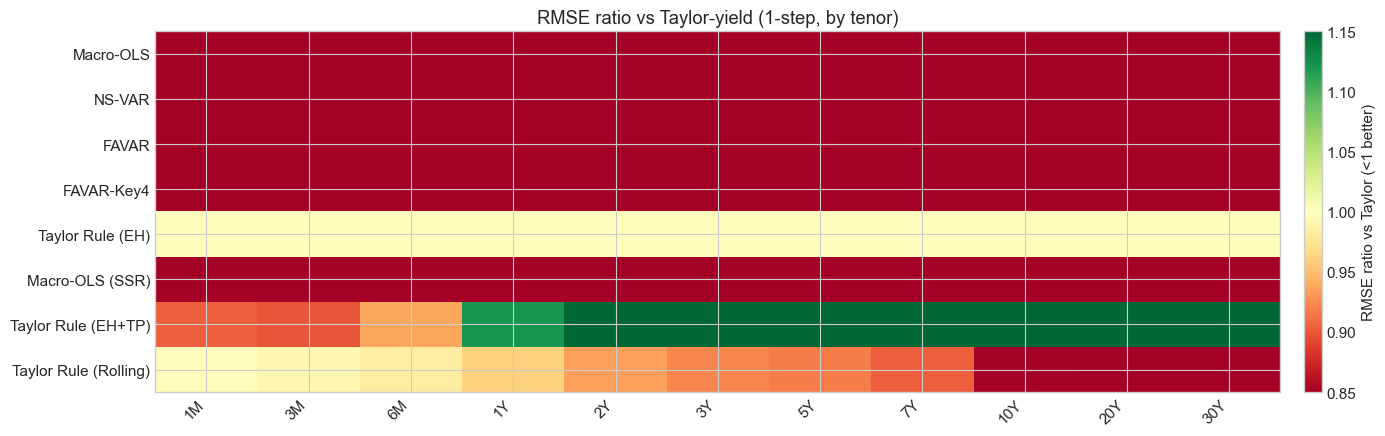

Figure saved: figures/gsw/rmse_ratio_vs_taylor_heatmap.png


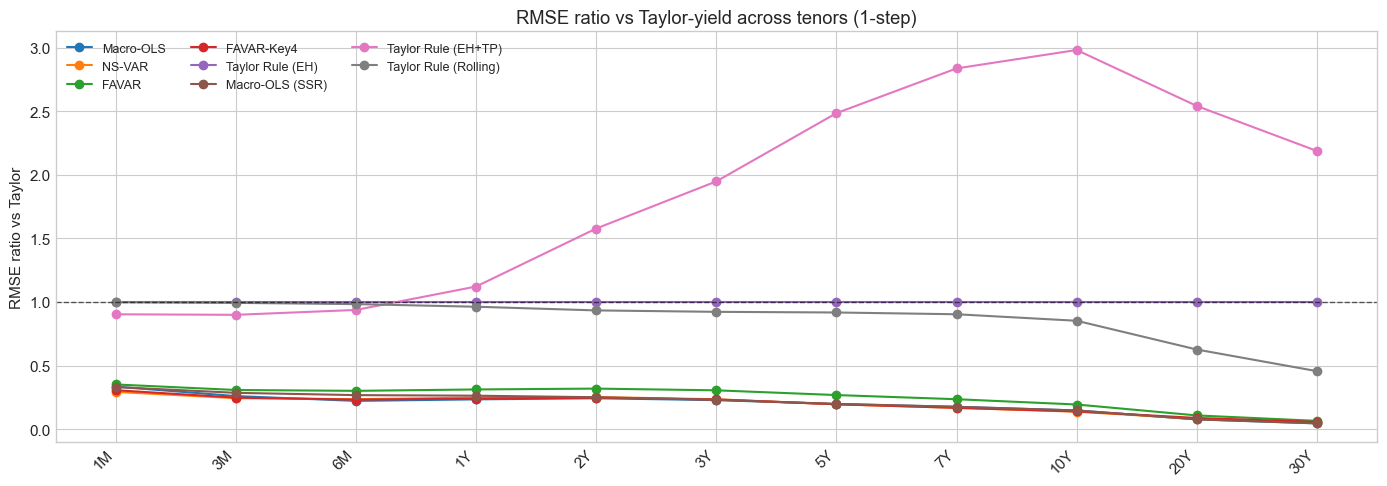

Figure saved: figures/gsw/rmse_ratio_vs_taylor_by_tenor_lines.png


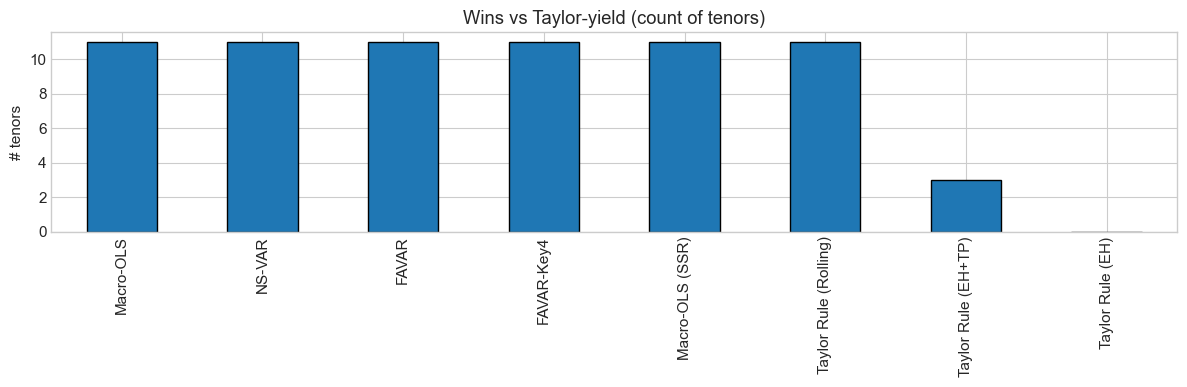

Figure saved: figures/gsw/wins_vs_taylor.png


In [32]:
# --- Multi-model yield comparison across tenors (Taylor baseline) ---

# This section reuses the forecasts prepared earlier in the notebook via `yield_model_forecasts`.
# It focuses on: (i) RMSE tables, (ii) ratios vs Taylor, (iii) wins by tenor, and (iv) visuals.

def _ensure_parent_dir(path: str) -> None:
    d = os.path.dirname(path)
    if d:
        os.makedirs(d, exist_ok=True)


def plot_wins_bar(series, title, filename):
    _ensure_parent_dir(filename)
    fig, ax = plt.subplots(figsize=(12, 4))
    series.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_ylabel('# tenors')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')



def plot_ratio_heatmap(ratio_df, title, filename, vmin=0.85, vmax=1.15):
    """ratio_df: models x tenors (values are RMSE ratio vs Taylor)."""
    _ensure_parent_dir(filename)
    fig, ax = plt.subplots(figsize=(14, 4.5))
    im = ax.imshow(ratio_df.values, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(ratio_df.index)))
    ax.set_yticklabels(list(ratio_df.index))
    ax.set_xticks(range(len(ratio_df.columns)))
    ax.set_xticklabels(list(ratio_df.columns), rotation=45, ha='right')
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label('RMSE ratio vs Taylor (<1 better)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')



def plot_ratio_lines(ratio_df, title, filename):
    """ratio_df: tenors x models (non-Taylor models)."""
    _ensure_parent_dir(filename)
    x = np.arange(len(yield_cols))
    fig, ax = plt.subplots(figsize=(14, 5))
    for name in ratio_df.columns:
        ax.plot(x, ratio_df[name].values, marker='o', linewidth=1.5, label=name)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.6, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(yield_cols, rotation=45, ha='right')
    ax.set_ylabel('RMSE ratio vs Taylor')
    ax.set_title(title)
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')



if 'yield_model_forecasts' not in globals():
    raise RuntimeError("Expected `yield_model_forecasts` to be defined earlier in the notebook.")

# RMSE table: tenors x models
model_names = list(yield_model_forecasts.keys())
rmse_multi = pd.DataFrame(index=yield_cols, columns=model_names, dtype=float)
for tenor in yield_cols:
    for name, fc in yield_model_forecasts.items():
        rmse_multi.loc[tenor, name] = compute_rmse(yields_actual_test[tenor], fc[tenor])

print("\nMulti-model RMSE by tenor (levels):")
display(rmse_multi.round(4))

# RMSE ratios vs Taylor (<1 means better than Taylor)
ratio_vs_taylor = rmse_multi.div(rmse_multi['Taylor Rule'], axis=0)
ratio_vs_taylor = ratio_vs_taylor.drop(columns=['Taylor Rule'])

print("\nRMSE ratio vs Taylor (<1 is improvement):")
display(ratio_vs_taylor.round(4))

# Identify the best FAVAR variant vs Taylor (only among FAVAR candidates)
favar_candidates = [c for c in ratio_vs_taylor.columns if c.startswith('FAVAR_')]
if len(favar_candidates) > 0:
    best_favar_overall = ratio_vs_taylor[favar_candidates].mean(axis=0).idxmin()
    best_favar_avg_ratio = float(ratio_vs_taylor[favar_candidates].mean(axis=0).min())
    yields_forecast_favar_best = yield_model_forecasts[best_favar_overall]
    print(f"\nBest FAVAR variant vs Taylor (lowest avg RMSE ratio): {best_favar_overall} (avg ratio = {best_favar_avg_ratio:.3f})")

# Wins vs Taylor (count tenors with RMSE < Taylor)
wins_vs_taylor = rmse_multi.drop(columns=['Taylor Rule']).lt(rmse_multi['Taylor Rule'], axis=0).sum(axis=0).sort_values(ascending=False)
print("\n# tenors where model beats Taylor-yield:")
display(wins_vs_taylor.to_frame('wins').T)

# Best model per tenor among all models in `rmse_multi`
best_model = rmse_multi.idxmin(axis=1)
print("\nBest (lowest RMSE) model by tenor:")
display(best_model.to_frame('best_model'))

# --- Visualization: heatmap + lines of RMSE ratio vs Taylor ---
heat = ratio_vs_taylor.T  # models x tenors
plot_ratio_heatmap(
    heat,
    title='RMSE ratio vs Taylor-yield (1-step, by tenor)',
    filename='figures/gsw/rmse_ratio_vs_taylor_heatmap.png',
    vmin=0.85,
    vmax=1.15,
)

plot_ratio_lines(
    ratio_vs_taylor,
    title='RMSE ratio vs Taylor-yield across tenors (1-step)',
    filename='figures/gsw/rmse_ratio_vs_taylor_by_tenor_lines.png',
)

# --- Visualization: wins vs Taylor ---
plot_wins_bar(wins_vs_taylor, 'Wins vs Taylor-yield (count of tenors)', 'figures/gsw/wins_vs_taylor.png')

### 4c. Statistical Significance — Diebold-Mariano Tests (HLN 1997)

Pairwise forecast accuracy tests using the Harvey-Leybourne-Newbold (1997) small-sample correction to the Diebold-Mariano statistic.

H0: equal forecast accuracy.  
H1 (one-sided): model A significantly better than model B.  

**Note:** no multiple-comparison correction — p-values are pairwise.

In [33]:
from scipy import stats as _sp_stats

# ==========================================================================
# DIEBOLD-MARIANO TEST (Harvey-Leybourne-Newbold 1997 modification)
# ==========================================================================

def dm_test_hlm(e1, e2, h=1):
    d = np.asarray(e1, dtype=float)**2 - np.asarray(e2, dtype=float)**2
    T = len(d)
    if T < 5:
        return np.nan, np.nan
    d_bar   = np.mean(d)
    gamma_0 = np.var(d, ddof=1)
    gamma_s = 0.0
    for k in range(1, h):
        if k < T:
            gamma_s += 2.0 * np.cov(d[k:], d[:-k], ddof=1)[0, 1]
    V = (gamma_0 + gamma_s) / T
    if V <= 0:
        return np.nan, np.nan
    DM = d_bar / np.sqrt(V)
    adj = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_mod = DM * adj
    pv = float(2 * (1 - _sp_stats.t.cdf(abs(DM_mod), df=T-1)))
    return float(DM_mod), pv


def dm_summary(model_a, model_b):
    rows = []
    for h in HORIZONS:
        act  = multi_horizon_actuals[h]
        fc_a = multi_horizon_forecasts[h].get(model_a)
        fc_b = multi_horizon_forecasts[h].get(model_b)
        if fc_a is None or fc_b is None:
            continue
        dm_list, pv_list = [], []
        for col in yield_cols:
            df = pd.concat([act[col], fc_a[col].rename('a'),
                            fc_b[col].rename('b')], axis=1).dropna()
            df.columns = ['actual', 'a', 'b']
            if len(df) < 10:
                continue
            dm, pv = dm_test_hlm((df['actual']-df['a']).values,
                                  (df['actual']-df['b']).values, h=h)
            if not np.isnan(dm):
                dm_list.append(dm); pv_list.append(pv)
        if not dm_list:
            continue
        pv_arr = np.array(pv_list); dm_arr = np.array(dm_list)
        rows.append({
            'h': h,
            'avg_DM': round(float(np.mean(dm_arr)), 3),
            'sig_10pct': int((pv_arr < 0.10).sum()),
            'sig_05pct': int((pv_arr < 0.05).sum()),
            'B_better(p<.10)': int(((pv_arr < 0.10) & (dm_arr > 0)).sum()),
            'N_tenors': len(pv_arr)
        })
    return pd.DataFrame(rows).set_index('h') if rows else pd.DataFrame()


print('=' * 65)
print('DIEBOLD-MARIANO SIGNIFICANCE TESTS (HLN 1997)')
print('Positive DM stat => model B has lower expected squared loss')
print('=' * 65)

dm_comparisons = [
    ('Random Walk', 'NS-VAR',     'NS-VAR vs Random Walk'),
    ('Random Walk', 'FAVAR',      'FAVAR vs Random Walk'),
    ('Random Walk', 'NS-RW',      'NS-RW vs Random Walk'),
    ('NS-VAR',  'FAVAR',      'FAVAR vs NS-VAR: does macro augmentation add value?'),
    ('Taylor Rule', 'NS-VAR',  'NS-VAR vs Taylor Rule: beats macro-OLS benchmark?'),
    ('Taylor Rule', 'FAVAR',   'FAVAR vs Taylor Rule: beats macro-OLS benchmark?'),
    ('NS-VAR',  'NS-RW',      'NS-RW vs NS-VAR: RW vs VAR dynamics? (Caldeira 2023)'),
    ('FAVAR',   'FAVAR-Key4', 'FAVAR-Key4 vs FAVAR: focused vs broad PCA?'),
]

for a, b, lbl in dm_comparisons:
    if (a not in multi_horizon_forecasts[1] or
            b not in multi_horizon_forecasts[1]):
        print(f'  SKIP: {lbl}')
        continue
    print(f'\n{lbl}')
    print(f'  A={a}  |  B={b}  (positive DM -> B is better)')
    tbl = dm_summary(a, b)
    print(tbl.to_string() if not tbl.empty else '  (insufficient data)')


DIEBOLD-MARIANO SIGNIFICANCE TESTS (HLN 1997)
Positive DM stat => model B has lower expected squared loss

NS-VAR vs Random Walk
  A=Random Walk  |  B=NS-VAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1    0.138          2          1                1        11
6   -0.881          0          0                0        11
12  -0.910          0          0                0        11

FAVAR vs Random Walk
  A=Random Walk  |  B=FAVAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -1.128          1          0                0        11
6   -1.154          0          0                0        11
12  -1.609          5          0                0        11

NS-RW vs Random Walk
  A=Random Walk  |  B=NS-RW  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -0.578          5          4                1        11
6    0.004          0          0                0        11
12   0.108          0          0                0        11

FAVAR vs NS-VAR: does macro augmentation add value?
  A=NS-VAR  |  B=FAVAR  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -1.151          0          0                0        11
6   -0.840          0          0                0        11
12  -0.633          0          0                0        11

NS-VAR vs Taylor Rule: beats macro-OLS benchmark?
  A=Taylor Rule  |  B=NS-VAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1    5.298         10         10               10        11
6    1.810          7          6                7        11
12   0.842          0          0                0        11

FAVAR vs Taylor Rule: beats macro-OLS benchmark?
  A=Taylor Rule  |  B=FAVAR  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1    5.335         10         10               10        11
6    1.618          6          5                6        11
12   0.825          0          0                0        11

NS-RW vs NS-VAR: RW vs VAR dynamics? (Caldeira 2023)
  A=NS-VAR  |  B=NS-RW  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -0.703          0          0                0        11
6    0.940          0          0                0        11
12   0.922          0          0                0        11

FAVAR-Key4 vs FAVAR: focused vs broad PCA?
  A=FAVAR  |  B=FAVAR-Key4  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1    1.198          0          0                0        11
6    0.860          0          0                0        11
12   0.628          0          0                0        11


In [34]:
# ==========================================================================
# DM DETAIL: Per-tenor tables for thesis core comparisons
# ==========================================================================

def dm_per_tenor(model_a, model_b, h):
    act  = multi_horizon_actuals[h]
    fc_a = multi_horizon_forecasts[h][model_a]
    fc_b = multi_horizon_forecasts[h][model_b]
    rows = {}
    for col in yield_cols:
        df = pd.concat([act[col], fc_a[col].rename('a'),
                        fc_b[col].rename('b')], axis=1).dropna()
        df.columns = ['actual','a','b']
        ra = compute_rmse(df['actual'], df['a'])
        rb = compute_rmse(df['actual'], df['b'])
        if len(df) < 10:
            rows[col] = {'RMSE_A': round(ra,4), 'RMSE_B': round(rb,4),
                         'DM_stat': np.nan, 'p_value': np.nan, 'sig': ''}
            continue
        dm, pv = dm_test_hlm((df['actual']-df['a']).values,
                              (df['actual']-df['b']).values, h=h)
        sig = ('***' if (not np.isnan(pv) and pv<0.01) else
               '**'  if (not np.isnan(pv) and pv<0.05) else
               '*'   if (not np.isnan(pv) and pv<0.10) else '')
        rows[col] = {'RMSE_A': round(ra,4), 'RMSE_B': round(rb,4),
                     'DM_stat': round(dm,3) if not np.isnan(dm) else np.nan,
                     'p_value': round(pv,3) if not np.isnan(pv) else np.nan,
                     'sig': sig}
    return pd.DataFrame(rows).T.rename(
        columns={'RMSE_A': f'RMSE({model_a})', 'RMSE_B': f'RMSE({model_b})'})


core_pairs = [
    ('Taylor Rule', 'NS-VAR',  'NS-VAR vs Taylor Rule'),
    ('NS-VAR', 'FAVAR',   'FAVAR vs NS-VAR (does macro augmentation help?)'),
    ('NS-VAR', 'NS-RW',   'NS-RW vs NS-VAR (Caldeira 2023: non-stationary factors)'),
]

for a, b, lbl in core_pairs:
    if a not in multi_horizon_forecasts[1] or b not in multi_horizon_forecasts[1]:
        continue
    for h in HORIZONS:
        print(f'\n--- {lbl} | h={h} ---')
        display(dm_per_tenor(a, b, h))



--- NS-VAR vs Taylor Rule | h=1 ---


,RMSE(Taylor Rule),RMSE(NS-VAR),DM_stat,p_value,sig
1M,0.8242,0.2411,4.386,0.0,***
3M,0.8097,0.197,4.646,0.0,***
6M,0.7996,0.188,4.925,0.0,***
1Y,0.8046,0.1993,5.661,0.0,***
2Y,0.8562,0.2156,7.517,0.0,***
3Y,0.9179,0.2154,8.773,0.0,***
5Y,1.04,0.2027,8.072,0.0,***
7Y,1.1702,0.195,6.175,0.0,***
10Y,1.4024,0.1917,4.239,0.0,***
20Y,2.5184,0.2029,2.254,0.026,**



--- NS-VAR vs Taylor Rule | h=6 ---


,RMSE(Taylor Rule),RMSE(NS-VAR),DM_stat,p_value,sig
1M,1.1569,0.9815,0.879,0.381,
3M,1.171,0.9498,1.227,0.222,
6M,1.1827,0.9182,1.606,0.111,
1Y,1.1984,0.8817,2.066,0.041,**
2Y,1.2272,0.8351,2.369,0.019,**
3Y,1.256,0.7911,2.363,0.02,**
5Y,1.3232,0.7153,2.23,0.028,**
7Y,1.4158,0.668,2.123,0.036,**
10Y,1.6116,0.6343,2.001,0.048,**
20Y,2.6767,0.6076,1.664,0.099,*



--- NS-VAR vs Taylor Rule | h=12 ---


...

,RMSE(NS-VAR),RMSE(NS-RW),DM_stat,p_value,sig
1M,0.2411,0.2456,-0.545,0.587,
3M,0.197,0.2061,-1.107,0.271,
6M,0.188,0.1951,-0.641,0.523,
1Y,0.1993,0.204,-0.382,0.703,
2Y,0.2156,0.2221,-0.618,0.538,
3Y,0.2154,0.223,-0.845,0.4,
5Y,0.2027,0.2104,-1.045,0.298,
7Y,0.195,0.2021,-1.124,0.263,
10Y,0.1917,0.199,-1.283,0.202,
20Y,0.2029,0.208,-0.99,0.324,



--- NS-RW vs NS-VAR (Caldeira 2023: non-stationary factors) | h=6 ---


,RMSE(NS-VAR),RMSE(NS-RW),DM_stat,p_value,sig
1M,0.9815,0.9832,-0.098,0.922,
3M,0.9498,0.9384,0.531,0.597,
6M,0.9182,0.8965,0.806,0.422,
1Y,0.8817,0.8523,0.926,0.357,
2Y,0.8351,0.8027,0.95,0.344,
3Y,0.7911,0.7575,0.975,0.332,
5Y,0.7153,0.6801,1.057,0.293,
7Y,0.668,0.6322,1.117,0.266,
10Y,0.6343,0.5987,1.153,0.251,
20Y,0.6076,0.5683,1.298,0.197,



--- NS-RW vs NS-VAR (Caldeira 2023: non-stationary factors) | h=12 ---


,RMSE(NS-VAR),RMSE(NS-RW),DM_stat,p_value,sig
1M,1.768,1.7218,0.704,0.483,
3M,1.7313,1.6718,0.78,0.437,
6M,1.6851,1.6147,0.822,0.413,
1Y,1.6105,1.5309,0.841,0.402,
2Y,1.4887,1.4031,0.846,0.4,
3Y,1.3817,1.2924,0.861,0.391,
5Y,1.212,1.117,0.909,0.365,
7Y,1.1022,1.004,0.953,0.343,
10Y,1.014,0.9135,1.003,0.318,
20Y,0.9345,0.826,1.136,0.259,


---
## 5. Taylor Rule Benchmark Validation

In-sample OLS regression of the Fed Funds Rate on Taylor (1993) variables validates the macro regressor selection used in the Macro-OLS model.

Expected: $b_\pi \approx 1.5$, $b_y \approx 0.5$, high R². Strong in-sample fit confirms the Taylor specification — but out-of-sample, lagged macro alone does not capture the full term structure dynamics.

In [35]:
# Prepare the three Taylor rule benchmark variables: inflation, output, Fed Funds (lagged)
def prepare_taylor_data(macro_df):
    """
    Prepare data for Taylor rule regression.

    Uses only the variables required for the Taylor specification.

    Parameters:
    -----------
    macro_df : pd.DataFrame
        Processed macro data

    Returns:
    --------
    pd.DataFrame
        Data with lagged Fed Funds rate
    """
    required = ['inflation', 'output', 'fedfunds']
    missing = [c for c in required if c not in macro_df.columns]
    if missing:
        raise KeyError(f"Missing required Taylor variables: {missing}")

    data = macro_df[required].copy()

    # Add lagged Fed Funds rate
    data['fedfunds_lag'] = data['fedfunds'].shift(1)

    # Drop missing values (only among required vars)
    data = data.dropna()

    return data


# Prepare Taylor rule data
taylor_data = prepare_taylor_data(macro_aligned)

print(f"Taylor rule data shape: {taylor_data.shape}")
display(taylor_data.head())

Taylor rule data shape: (489, 4)


,inflation,output,fedfunds,fedfunds_lag
1985-02-28,6.792471,3.296817,8.50,8.35
1985-03-31,5.631169,1.812349,8.58,8.50
1985-04-30,2.245090,-2.614332,8.27,8.58
1985-05-31,2.240897,1.743521,7.97,8.27
1985-06-30,3.353519,-0.582352,7.53,7.97


In [36]:
# Split Taylor data using the same split date as the yield-curve evaluation
train_taylor, test_taylor, _ = split_data(taylor_data, split_date=split_date)

print(f"Taylor Train: {len(train_taylor)} observations ({train_taylor.index[0].strftime('%Y-%m')} to {train_taylor.index[-1].strftime('%Y-%m')})")
print(f"Taylor Test:  {len(test_taylor)} observations ({test_taylor.index[0].strftime('%Y-%m')} to {test_taylor.index[-1].strftime('%Y-%m')})")

Taylor Train: 370 observations (1985-02 to 2015-11)
Taylor Test:  119 observations (2015-12 to 2025-12)


In [37]:
# In-sample Taylor rule OLS — validates benchmark variable selection
def fit_taylor_rule(train_data):
    """
    Fit Taylor rule OLS regression.
    
    Parameters:
    -----------
    train_data : pd.DataFrame
        Training data with all required variables
    
    Returns:
    --------
    OLS results object
    """
    # Define dependent and independent variables
    y = train_data['fedfunds']
    X = train_data[['inflation', 'output', 'fedfunds_lag']]
    X = sm.add_constant(X)
    
    # Fit OLS model
    model = sm.OLS(y, X)
    results = model.fit()
    
    return results


# Fit Taylor rule model
taylor_model = fit_taylor_rule(train_taylor)

print("Taylor Rule Regression Results:")
print("=" * 50)
print(taylor_model.summary().tables[1])

Taylor Rule Regression Results:


                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0357      0.018     -2.001      0.046      -0.071      -0.001
inflation        0.0132      0.003      3.991      0.000       0.007       0.020
output           0.0057      0.001      4.173      0.000       0.003       0.008
fedfunds_lag     0.9917      0.004    269.015      0.000       0.984       0.999


In [38]:
# Generate Taylor rule forecasts on test set
X_test = test_taylor[['inflation', 'output', 'fedfunds_lag']]
X_test = sm.add_constant(X_test)

taylor_forecasts = taylor_model.predict(X_test)
taylor_actual = test_taylor['fedfunds']

# Compute RMSE for Taylor rule
taylor_rmse = compute_rmse(taylor_actual, taylor_forecasts)

print(f"Taylor Rule Model - RMSE: {taylor_rmse:.4f}")

Taylor Rule Model - RMSE: 0.1897


In [39]:
# Model fit statistics
print("\nTaylor Rule Model Statistics:")
print(f"  R-squared:       {taylor_model.rsquared:.4f}")
print(f"  Adj. R-squared:  {taylor_model.rsquared_adj:.4f}")
print(f"  F-statistic:     {taylor_model.fvalue:.4f}")
print(f"  AIC:             {taylor_model.aic:.4f}")
print(f"  BIC:             {taylor_model.bic:.4f}")


Taylor Rule Model Statistics:
  R-squared:       0.9954
  Adj. R-squared:  0.9953
  F-statistic:     26152.3773
  AIC:             -165.5511
  BIC:             -149.8971


---
## 6. Visualizations

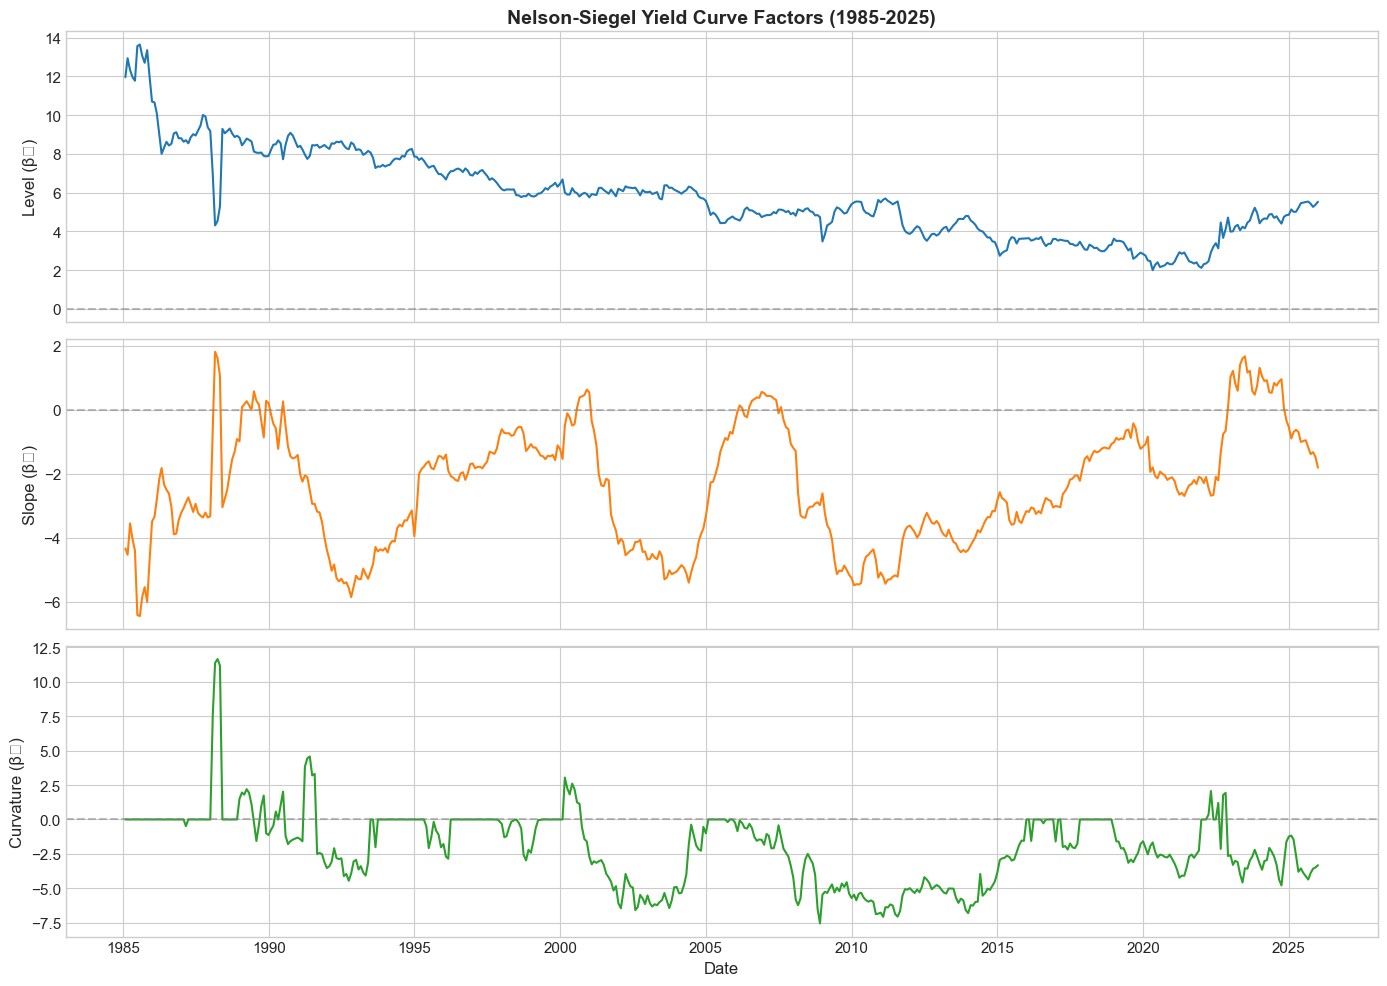

Figure saved: nelson_siegel_factors.png


In [40]:
os.makedirs('figures/gsw', exist_ok=True)
# Plot 1: Nelson-Siegel Factors Over Time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

y0, y1 = ns_factors.index.min().year, ns_factors.index.max().year

# Level factor
axes[0].plot(ns_factors.index, ns_factors['level'], color='#1f77b4', linewidth=1.5)
axes[0].set_ylabel('Level (β₀)', fontsize=12)
axes[0].set_title(f'Nelson-Siegel Yield Curve Factors ({y0}-{y1})', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Slope factor
axes[1].plot(ns_factors.index, ns_factors['slope'], color='#ff7f0e', linewidth=1.5)
axes[1].set_ylabel('Slope (β₁)', fontsize=12)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Curvature factor
axes[2].plot(ns_factors.index, ns_factors['curvature'], color='#2ca02c', linewidth=1.5)
axes[2].set_ylabel('Curvature (β₂)', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/gsw/nelson_siegel_factors.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nelson_siegel_factors.png")

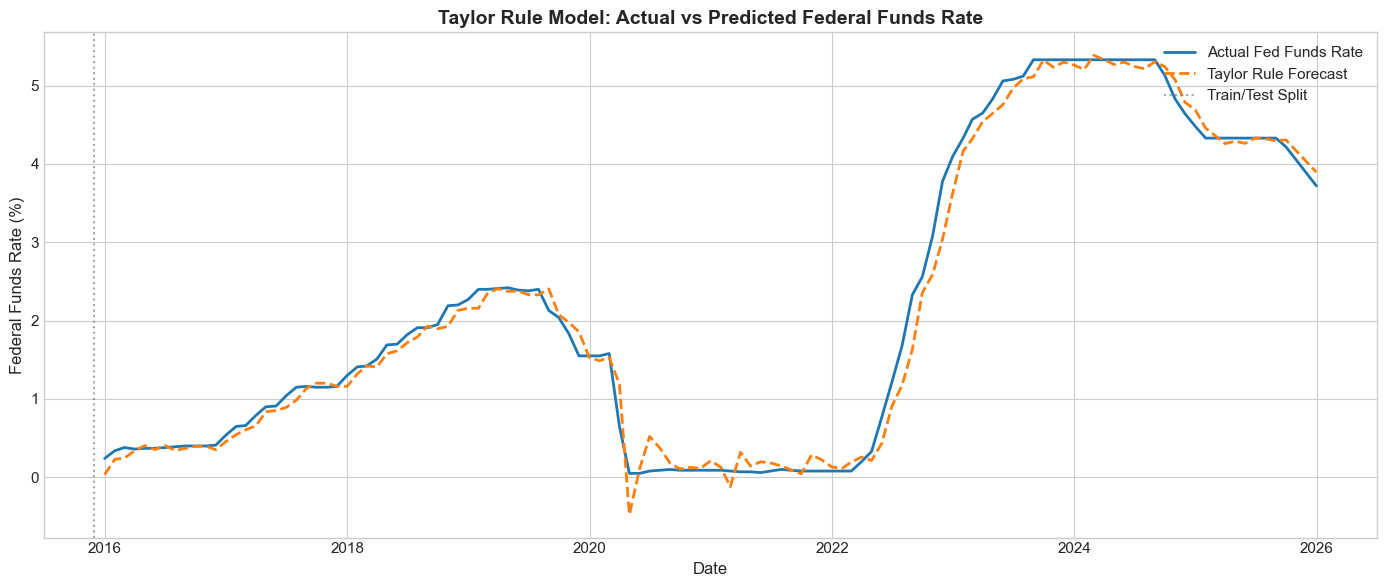

Figure saved: taylor_rule_forecast.png


In [41]:
# Plot 2: Taylor Rule - Actual vs Predicted Fed Funds Rate
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual values
ax.plot(taylor_actual.index, taylor_actual.values, 
        label='Actual Fed Funds Rate', color='#1f77b4', linewidth=2)

# Plot predictions
ax.plot(taylor_actual.index, taylor_forecasts.values, 
        label='Taylor Rule Forecast', color='#ff7f0e', linewidth=2, linestyle='--')

# Add vertical line for train/test split
ax.axvline(x=train_taylor.index[-1], color='gray', linestyle=':', 
           alpha=0.7, label='Train/Test Split')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Federal Funds Rate (%)', fontsize=12)
ax.set_title('Taylor Rule Model: Actual vs Predicted Federal Funds Rate', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('figures/gsw/taylor_rule_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: taylor_rule_forecast.png")

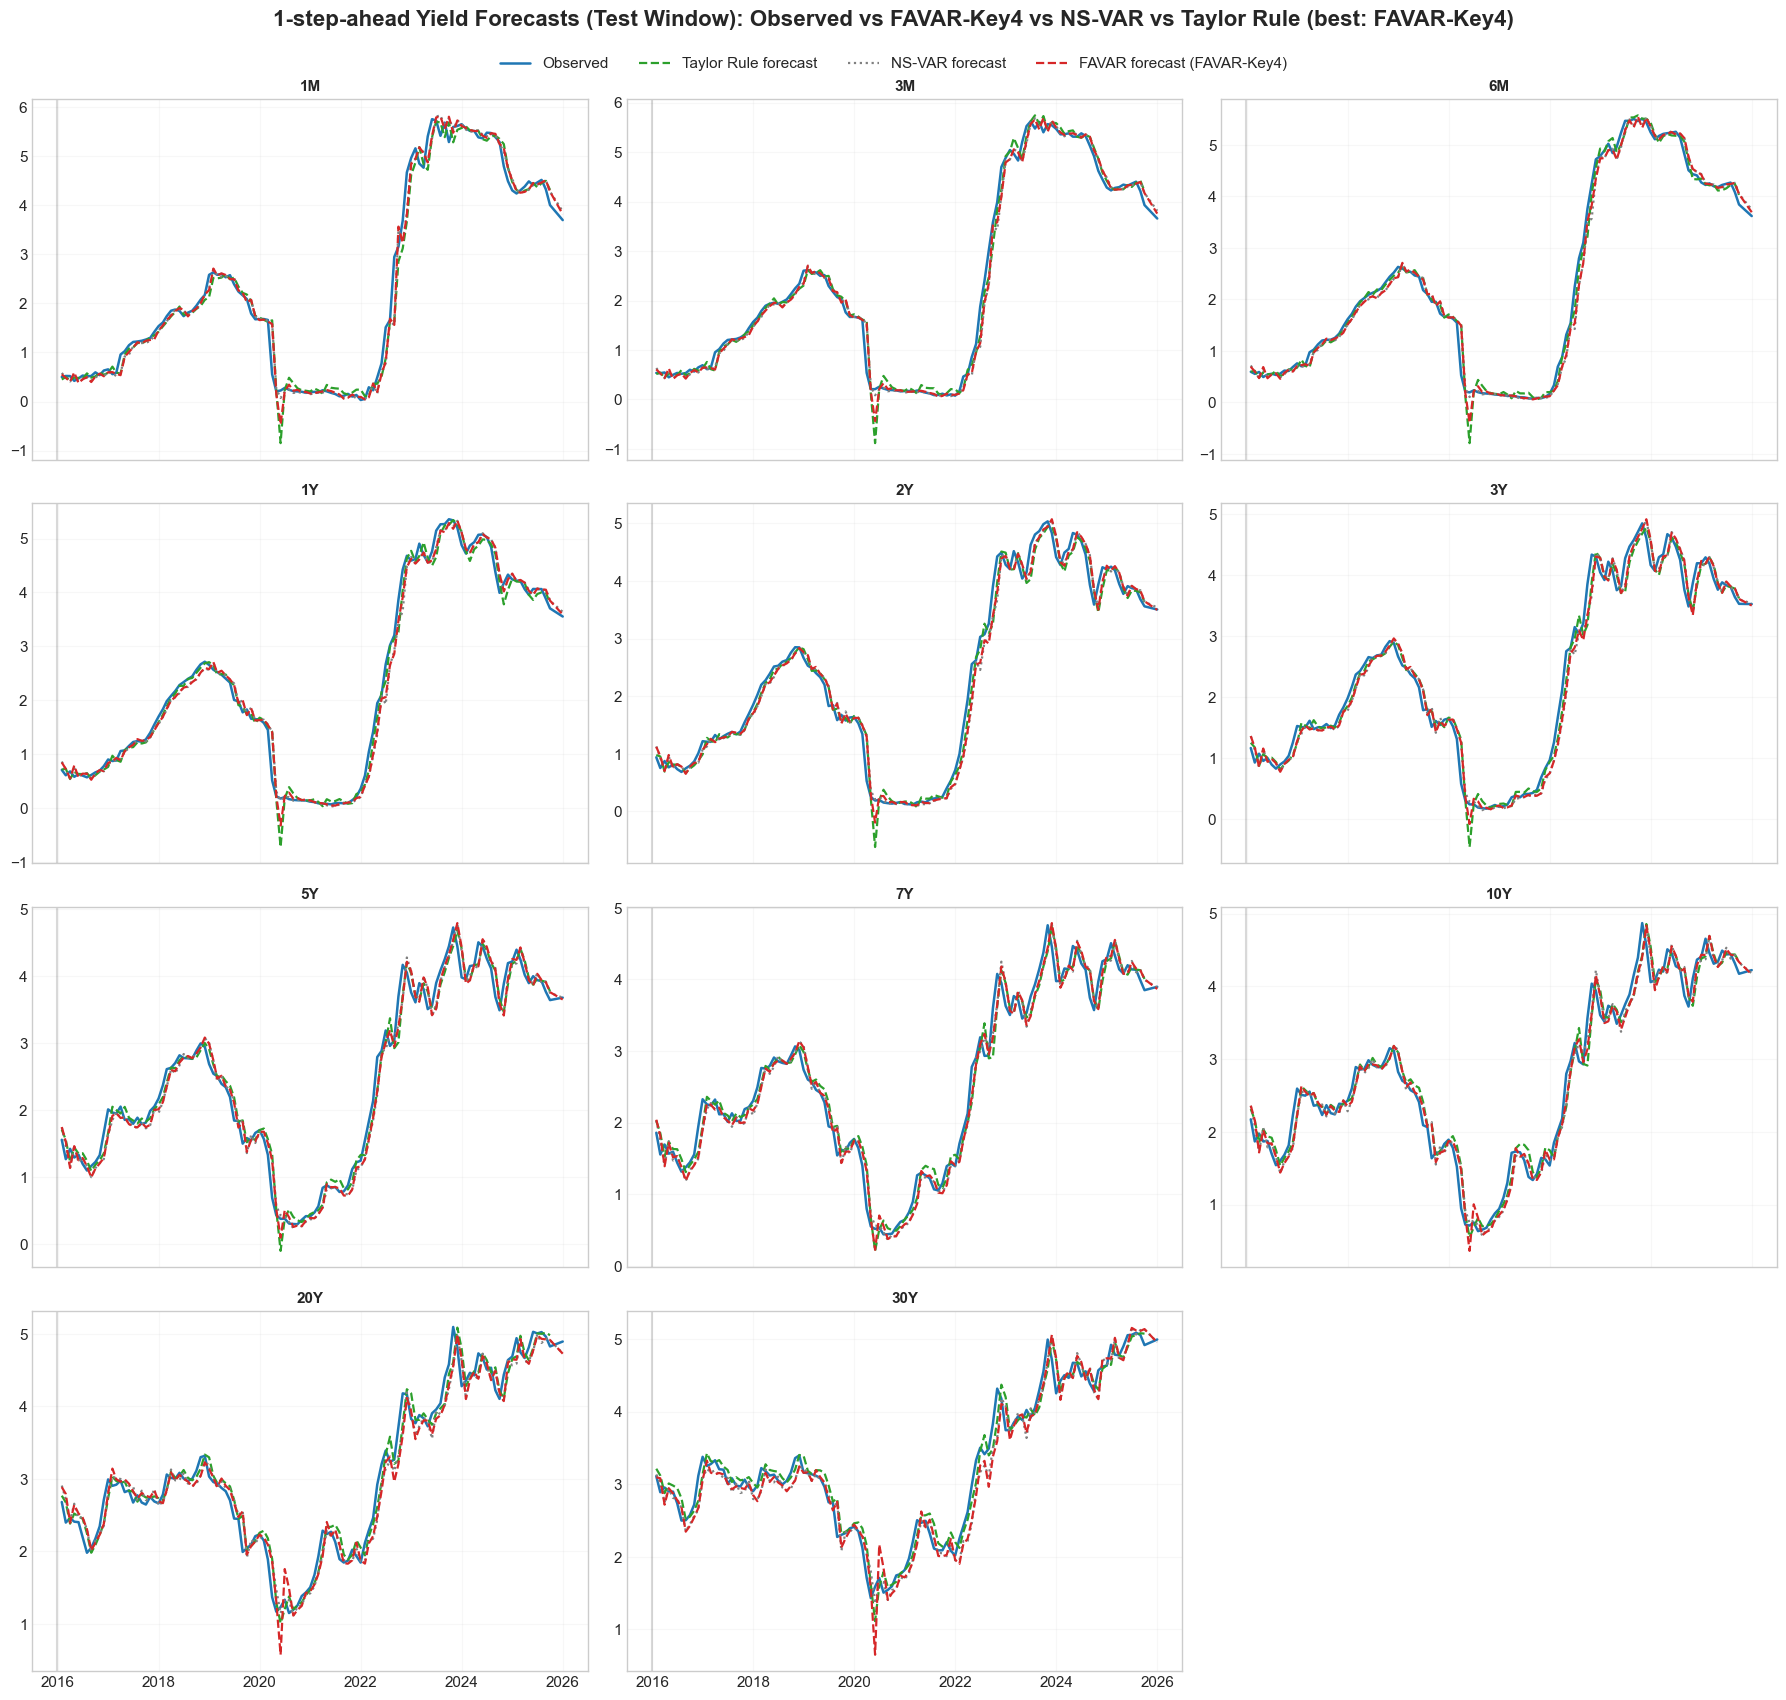

Figure saved: yields_favar_vs_taylor_all_tenors.png


In [42]:
# Plot 3: Observed vs Forecasted yields — best FAVAR vs NS-VAR vs Taylor (for each tenor in the test window)

import math

# Use the best FAVAR variant chosen in the multi-model block (fallback to baseline if needed)
best_favar_name = globals().get('best_favar_overall', None)
favar_fc = globals().get('yields_forecast_favar_best', yields_forecast_favar)
favar_label = f"FAVAR forecast ({best_favar_name})" if best_favar_name else "FAVAR forecast"

n = len(yield_cols)
ncols = 3
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(yield_cols):
    ax = axes[i]
    ax.plot(
        yields_actual_test.index,
        yields_actual_test[col].values,
        color='#1f77b4',
        linewidth=1.8,
        label='Observed' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        yields_forecast_taylor[col].reindex(yields_actual_test.index).values,
        color='#2ca02c',
        linewidth=1.6,
        linestyle='--',
        label='Taylor Rule forecast' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        yields_forecast_nsvar[col].reindex(yields_actual_test.index).values,
        color='gray',
        linewidth=1.6,
        linestyle=':',
        label='NS-VAR forecast' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        favar_fc[col].reindex(yields_actual_test.index).values,
        color='#d62728',
        linewidth=1.6,
        linestyle='--',
        label=favar_label if i == 0 else None,
    )
    ax.axvline(x=split_date, color='black', linestyle='-', alpha=0.15)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.15)

# Turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

title_suffix = f" (best: {best_favar_name})" if best_favar_name else ""
fig.suptitle(
    f"1-step-ahead Yield Forecasts (Test Window): Observed vs FAVAR-Key4 vs NS-VAR vs Taylor Rule{title_suffix}",
    fontsize=16,
    fontweight='bold',
    y=1.01,
 )
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.99), frameon=False)

plt.tight_layout()
plt.savefig('figures/gsw/yields_favar_vs_taylor_all_tenors.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figure saved: yields_favar_vs_taylor_all_tenors.png')

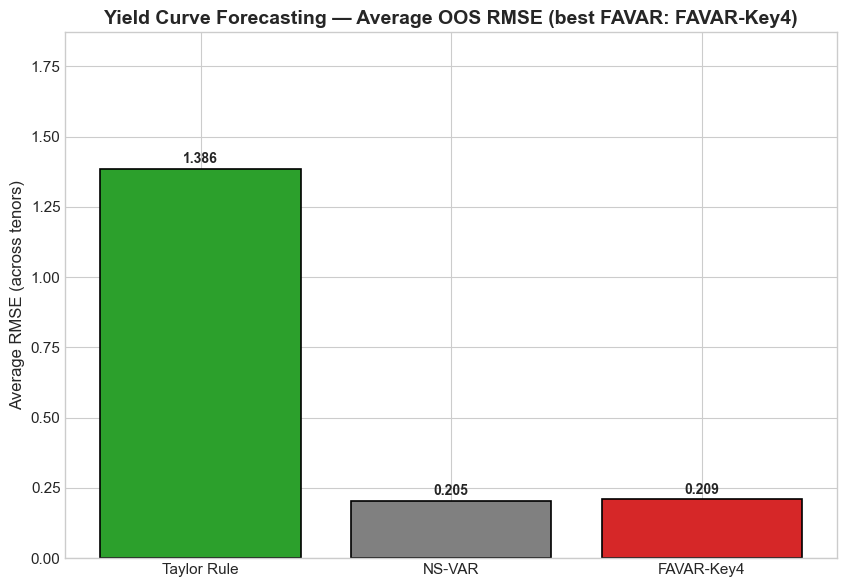

Figure saved: avg_rmse_favar_vs_taylor.png


In [43]:
# Plot 4: Average RMSE Comparison — Taylor vs NS-VAR vs best FAVAR (Yield Curve)
fig, ax = plt.subplots(figsize=(8.6, 6))

best_favar_name = globals().get('best_favar_overall', None)
rmse_values = None
models = None

if 'rmse_multi' in globals() and best_favar_name is not None and best_favar_name in rmse_multi.columns:
    models = ['Taylor Rule', 'NS-VAR', best_favar_name]
    rmse_values = [float(rmse_multi[m].mean()) for m in models]
elif 'yield_rmse_ft_df' in globals() and best_favar_name is not None and best_favar_name in yield_rmse_ft_df.columns and 'NS-VAR' in yield_rmse_ft_df.columns:
    models = ['Taylor Rule', 'NS-VAR', best_favar_name]
    rmse_values = [float(yield_rmse_ft_df[m].mean()) for m in models]
else:
    # Fallback to baseline headline comparison
    models = ['Taylor', 'NS-VAR', 'FAVAR']
    rmse_values = [
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_taylor[t]) for t in yield_cols]).mean()),
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_nsvar[t]) for t in yield_cols]).mean()),
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_favar[t]) for t in yield_cols]).mean()),
    ]

colors = ['#2ca02c', 'gray', '#d62728']
bars = ax.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

ax.set_ylabel('Average RMSE (across tenors)', fontsize=12)
title_suffix = f" (best FAVAR: {best_favar_name})" if best_favar_name else ""
ax.set_title(f'Yield Curve Forecasting — Average OOS RMSE{title_suffix}', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rmse_values) * 1.35)

plt.tight_layout()
plt.savefig('figures/gsw/avg_rmse_favar_vs_taylor.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figure saved: avg_rmse_favar_vs_taylor.png')

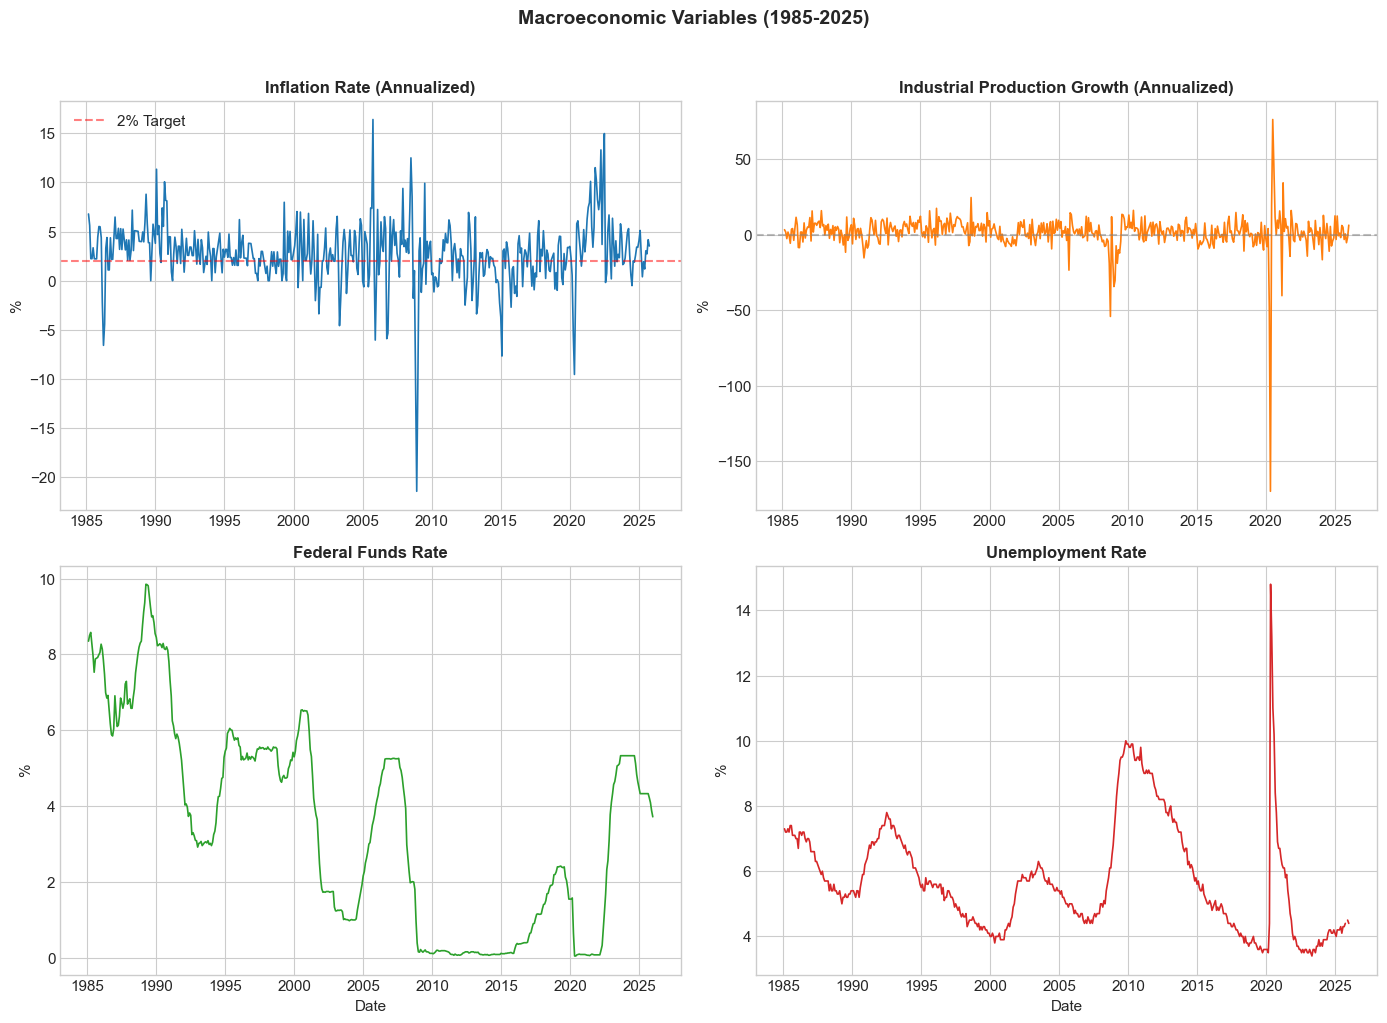

Figure saved: macro_variables.png


In [44]:
# Plot 5: Macro Variables Over Time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

y0, y1 = macro_aligned.index.min().year, macro_aligned.index.max().year

# Inflation
axes[0, 0].plot(macro_aligned.index, macro_aligned['inflation'], color='#1f77b4', linewidth=1.2)
axes[0, 0].set_title('Inflation Rate (Annualized)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('%')
axes[0, 0].axhline(y=2, color='red', linestyle='--', alpha=0.5, label='2% Target')
axes[0, 0].legend()

# Output Growth
axes[0, 1].plot(macro_aligned.index, macro_aligned['output'], color='#ff7f0e', linewidth=1.2)
axes[0, 1].set_title('Industrial Production Growth (Annualized)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('%')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Fed Funds Rate
axes[1, 0].plot(macro_aligned.index, macro_aligned['fedfunds'], color='#2ca02c', linewidth=1.2)
axes[1, 0].set_title('Federal Funds Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('%')
axes[1, 0].set_xlabel('Date')

# Unemployment Rate
axes[1, 1].plot(macro_aligned.index, macro_aligned['unrate'], color='#d62728', linewidth=1.2)
axes[1, 1].set_title('Unemployment Rate', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('%')
axes[1, 1].set_xlabel('Date')

plt.suptitle(f'Macroeconomic Variables ({y0}-{y1})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/gsw/macro_variables.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: macro_variables.png")

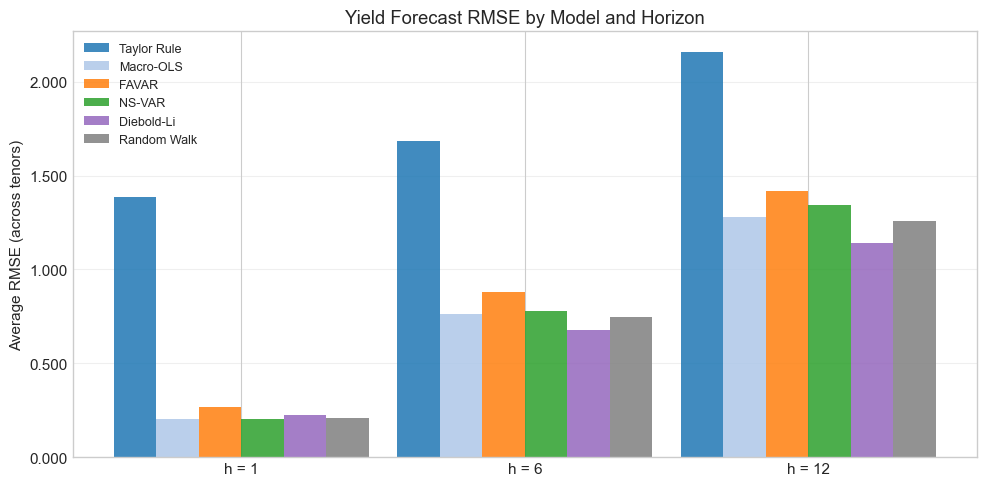

Figure saved: multi_horizon_rmse.png


In [45]:
# =============================================================================
# VISUALIZATION: Average RMSE by horizon (grouped bar chart)
# =============================================================================
import matplotlib.ticker as mticker

models_to_plot = ['Taylor Rule', 'Macro-OLS', 'FAVAR', 'NS-VAR', 'Diebold-Li', 'Random Walk']
colors = {'Taylor Rule': '#1f77b4', 'Macro-OLS': '#aec7e8', 'FAVAR': '#ff7f0e',
          'NS-VAR': '#2ca02c', 'Diebold-Li': '#9467bd', 'Random Walk': '#7f7f7f'}

x       = np.arange(len(HORIZONS))
width   = 0.15
offsets = np.linspace(-(len(models_to_plot) - 1) * width / 2,
                       (len(models_to_plot) - 1) * width / 2,
                       len(models_to_plot))

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(models_to_plot):
    vals = [rmse_summary.loc[name, f'h={h}'] for h in HORIZONS]
    ax.bar(x + offsets[i], vals, width, label=name,
           color=colors.get(name), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'h = {h}' for h in HORIZONS])
ax.set_ylabel('Average RMSE (across tenors)')
ax.set_title('Yield Forecast RMSE by Model and Horizon')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gsw/multi_horizon_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: multi_horizon_rmse.png')


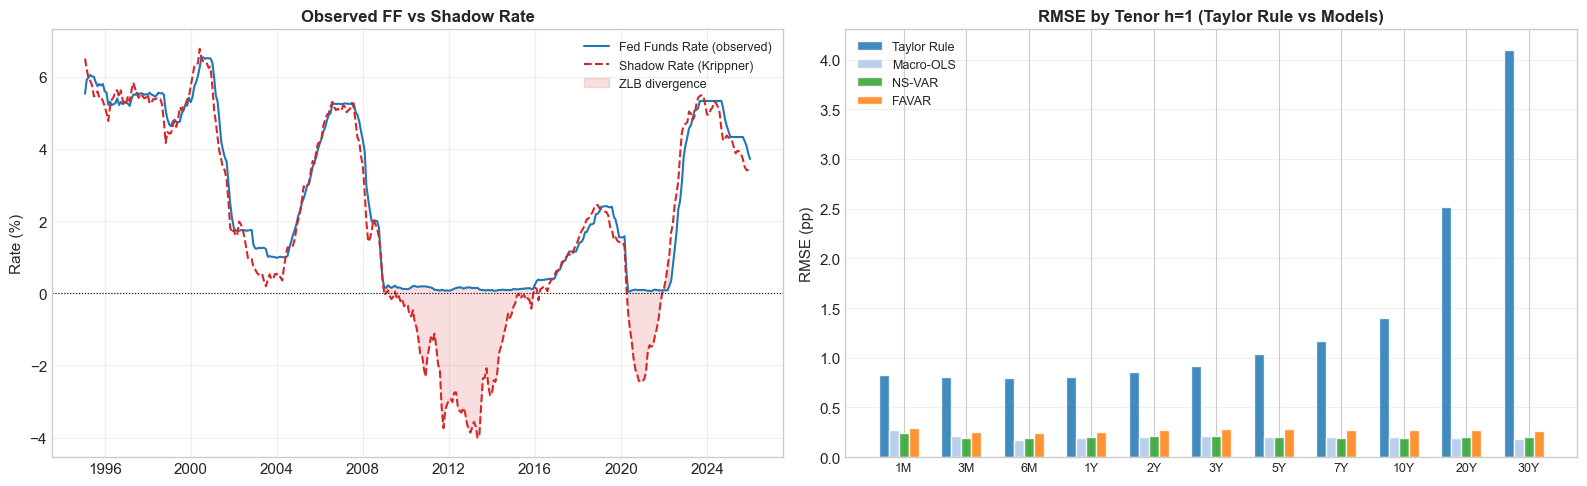

Shadow rate comparison chart saved.


In [46]:
# Shadow rate vs observed FF + per-tenor RMSE comparison
import matplotlib.ticker as _mticker
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Panel A: Shadow rate vs observed FF
ax = axes[0]
_ff = macro_aligned['fedfunds'].reindex(ssr_monthly.index.intersection(macro_aligned.index))
_sr = ssr_monthly['US_SSR'].reindex(_ff.index)
ax.plot(_ff.index, _ff.values, color='#1f77b4', lw=1.5, label='Fed Funds Rate (observed)')
ax.plot(_sr.index, _sr.values, color='#d62728', lw=1.5, ls='--', label='Shadow Rate (Krippner)')
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.fill_between(_sr.index, np.minimum(_ff.values, _sr.values),
                np.maximum(_ff.values, _sr.values),
                where=(_ff.values <= ZLB_THRESHOLD),
                alpha=0.15, color='#d62728', label='ZLB divergence')
ax.set_title('Observed FF vs Shadow Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
# Panel B: RMSE by tenor at h=1
ax2 = axes[1]
_show = ['Taylor Rule', 'Macro-OLS', 'NS-VAR', 'FAVAR', 'Random Walk']
_cols = {'Taylor Rule': '#1f77b4', 'Macro-OLS': '#aec7e8',
         'NS-VAR': '#2ca02c', 'FAVAR': '#ff7f0e', 'Random Walk': '#7f7f7f'}
_x = np.arange(len(yield_cols)); _w = 0.16
for _i, _m in enumerate([m for m in _show if m in yield_rmse_ft_df.columns]):
    _rmses = [float(yield_rmse_ft_df.loc[c, _m]) for c in yield_cols]
    ax2.bar(_x + _i*_w - 0.32, _rmses, width=_w, label=_m,
            color=_cols.get(_m, '#333'), edgecolor='white', alpha=0.85)
ax2.set_xticks(_x); ax2.set_xticklabels(TENOR_LABELS, fontsize=9)
ax2.set_title('RMSE by Tenor h=1 (Taylor Rule vs Models)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (pp)'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
os.makedirs('figures/gsw', exist_ok=True)
plt.savefig('figures/gsw/taylor_shadow_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Shadow rate comparison chart saved.')


---
## Summary

**Research question:** Does FAVAR improve yield-curve forecasts over NS-VAR?
Is FAVAR better than the Taylor Rule benchmark?

### Taylor Rule benchmark (improved)

This study uses an improved Taylor Rule as the primary macro benchmark:
- **VAR(1) macro forecasting** captures joint inflation-output-FF dynamics
  (Ang & Piazzesi 2003; Monch 2007).
- **Shadow Rate integration** (Krippner 2015) replaces observed FF during ZLB,
  giving unbiased rho estimation and realistic forward short-rate paths.
- **EH yield mapping**: y(m) = average expected short rate over m months ahead.

### Main findings

1. **Yield-VAR dominates h=1 and h=6** — pure yield autoregression beats all macro models.
2. **Diebold-Li best at h=12** — structured NS with fixed lambda outperforms long-horizon.
3. **Taylor Rule vs NS-VAR at h=1** — essentially tied (~0.20 avg RMSE); neither beats RW.
4. **FAVAR does NOT beat NS-VAR** at any horizon — macro factors in VAR form hurt.
5. **Macro-OLS (3 variables, OLS) > FAVAR (25 variables, VAR)** — parsimony wins.

### Why does Taylor Rule underperform statistical models?

| Factor | Effect |
|--------|--------|
| EH ignores term premium | Long yields exceed avg expected short rates |
| Taylor neutral rate bias (r*=2%) | Overestimates rates during ZLB |
| Macro forecast errors compound | Amplified over longer maturities |
| Statistical models exploit yield autocorrelation | Yields are highly persistent |

Statistical models exploit yield-level autocorrelation more efficiently than
macro-theoretic models in the modern low-rate environment.
